###Install dependencies

In [ ]:
!pip install -q yfinance xgboost lightgbm tensorflow scikit-learn statsmodels pandas numpy matplotlib seaborn hmmlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 13.1 MB/s eta 0:00:00


###Install import packages

In [ ]:
import sys, os, time, logging, warnings, io, zipfile, itertools
from pathlib import Path
from typing import Iterable, Optional, Tuple, List, Dict, Any
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests

import xgboost as xgb
import lightgbm as lgb
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.linear_model import LinearRegression

import tensorflow as tf
from tensorflow.keras import Sequential, layers, callbacks, utils

from statsmodels.tsa.stattools import coint
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(asctime)s [%(levelname)s] %(message)s')
log = logging.getLogger(__name__)

###Configuration

In [ ]:
CONFIG = {
    'start_date': '2010-01-01',
    'end_date': '2025-12-31',
    'cache_dir': 'data_cache',
    'price_cache_dir': 'data_cache/prices',
    'ff5_cache_dir': 'data_cache/factors',
    'batch_size': 25,
    'sleep_between_batches': 3.0,
    'max_retries': 4,
    'cointegration_p_threshold': 0.10,
    'cointegration_min_obs': 500,
    'rolling_window_years': 2,
    'rolling_step_months': 6,
    'shortlist_threshold': 30,
    'feature_z_window': 60,
    'label_horizon': 5,
    'label_z_entry': 2.0,
    'train_end': '2018-12-31',
    'val_end': '2021-12-31',
    'capital_per_pair': 100_000,
    'txn_cost_bps': 7.5,
    'slippage_bps': 3.0,
    'random_state': 42,
    'n_backtest_pairs': 10,
}

Path(CONFIG['cache_dir']).mkdir(parents=True, exist_ok=True)
Path(CONFIG['price_cache_dir']).mkdir(parents=True, exist_ok=True)
Path(CONFIG['ff5_cache_dir']).mkdir(parents=True, exist_ok=True)

In [ ]:
import shutil
from pathlib import Path

cache_dir = Path("data_cache/prices")
if cache_dir.exists():
    shutil.rmtree(cache_dir)
cache_dir.mkdir(parents=True, exist_ok=True)
print("Cleared price cache -- next run will re-download everything from scratch.")

Cleared price cache -- next run will re-download everything from scratch.


###Data Ingestion

In [ ]:
%%writefile data_ingestion.py
from __future__ import annotations
import io, time, zipfile, logging
from pathlib import Path
from typing import Iterable
import numpy as np
import pandas as pd
import requests

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
log = logging.getLogger(__name__)

FF5_DAILY_URL = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_5_Factors_2x3_daily_CSV.zip"

def download_prices(tickers, start, end, cache_dir="data_cache/prices", batch_size=25, sleep_between_batches=3.0, max_retries=4):
    import yfinance as yf
    cache_path = Path(cache_dir)
    cache_path.mkdir(parents=True, exist_ok=True)
    tickers = list(dict.fromkeys(tickers))
    to_fetch, cached_frames = [], []
    for t in tickers:
        f = cache_path / f"{t}.parquet"
        if f.exists():
            cached_frames.append(pd.read_parquet(f))
        else:
            to_fetch.append(t)
    log.info(f"{len(tickers) - len(to_fetch)} cached, {len(to_fetch)} to download")
    fetched_frames = []
    for i in range(0, len(to_fetch), batch_size):
        batch = to_fetch[i:i+batch_size]
        attempt = 0
        while attempt <= max_retries:
            try:
                log.info(f"Downloading batch {i//batch_size + 1}: {batch}")
                raw = yf.download(batch, start=start, end=end, auto_adjust=False, group_by="ticker", threads=True, progress=False)
                break
            except Exception as e:
                attempt += 1
                wait = sleep_between_batches * (2 ** attempt)
                log.warning(f"Batch failed ({e}); retry {attempt}/{max_retries} in {wait:.0f}s")
                time.sleep(wait)
        else:
            log.error(f"Batch {batch} failed -- skipping")
            continue
        for t in batch:
            try:
                sub = raw[t].copy() if len(batch) > 1 else raw.copy()
            except (KeyError, TypeError):
                log.warning(f"No data for {t}")
                continue
            sub = sub.rename(columns={"Open": "open", "High": "high", "Low": "low", "Close": "close", "Adj Close": "adj_close", "Volume": "volume"})
            sub.index.name = "date"
            sub = sub.reset_index()
            sub["ticker"] = t
            sub = sub.dropna(subset=["adj_close"])
            if sub.empty:
                continue
            sub.to_parquet(cache_path / f"{t}.parquet", index=False)
            fetched_frames.append(sub)
        time.sleep(sleep_between_batches)
    all_frames = cached_frames + fetched_frames
    if not all_frames:
        raise RuntimeError("No price data retrieved.")
    panel = pd.concat(all_frames, ignore_index=True)
    panel["date"] = pd.to_datetime(panel["date"])
    return panel.sort_values(["ticker", "date"]).reset_index(drop=True)

def download_ff5_daily(cache_dir="data_cache/factors"):
    cache_path = Path(cache_dir)
    cache_path.mkdir(parents=True, exist_ok=True)
    cache_file = cache_path / "ff5_daily.parquet"
    if cache_file.exists():
        return pd.read_parquet(cache_file)
    resp = requests.get(FF5_DAILY_URL, timeout=30)
    resp.raise_for_status()
    z = zipfile.ZipFile(io.BytesIO(resp.content))
    csv_name = [n for n in z.namelist() if n.lower().endswith(".csv")][0]
    raw_text = z.read(csv_name).decode("utf-8", errors="ignore")
    lines = raw_text.splitlines()
    header_idx = next(i for i, l in enumerate(lines) if "Mkt-RF" in l)
    data_lines = lines[header_idx:]
    end_idx = len(data_lines)
    for i, l in enumerate(data_lines[1:], start=1):
        first_tok = l.split(",")[0].strip()
        if not first_tok.isdigit() or len(first_tok) != 8:
            end_idx = i
            break
    df = pd.read_csv(io.StringIO("\n".join(data_lines[:end_idx])))
    df = df.rename(columns={df.columns[0]: "date", "Mkt-RF": "mkt_rf", "SMB": "smb", "HML": "hml", "RMW": "rmw", "CMA": "cma", "RF": "rf"})
    df["date"] = pd.to_datetime(df["date"], format="%Y%m%d")
    factor_cols = ["mkt_rf", "smb", "hml", "rmw", "cma", "rf"]
    df[factor_cols] = df[factor_cols].apply(pd.to_numeric, errors="coerce") / 100.0
    df = df.dropna(subset=factor_cols).reset_index(drop=True)
    df.to_parquet(cache_file, index=False)
    return df

def load_price_panel(cache_dir="data_cache/prices"):
    cache_path = Path(cache_dir)
    files = list(cache_path.glob("*.parquet"))
    if not files:
        raise FileNotFoundError(f"No cached price files in {cache_dir}.")
    return pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)

def sanity_check_panel(panel):
    report = []
    for t, g in panel.groupby("ticker"):
        g = g.sort_values("date")
        n_days = (g["date"].max() - g["date"].min()).days
        expected = n_days * 5 / 7
        report.append({"ticker": t, "start": g["date"].min().date(), "end": g["date"].max().date(), "n_obs": len(g), "approx_expected": int(expected), "coverage_pct": round(100 * len(g) / max(expected, 1), 1), "min_adj_close": g["adj_close"].min(), "has_nonpositive_price": bool((g["adj_close"] <= 0).any())})
    return pd.DataFrame(report).sort_values("coverage_pct")

Writing data_ingestion.py


###The stock universe

In [ ]:
%%writefile universe.py
from __future__ import annotations
from collections import Counter

ORIGINAL_22 = ["JPM","BAC","WFC","C","USB","PNC","XOM","CVX","COP","EOG","KO","PEP","TGT","WMT","V","MA","SPG","O","DAL","UAL","LUV","AAL"]

EXPANSION_BY_SECTOR = {
    "banks": ["GS","MS","SCHW","TFC","COF"],
    "energy": ["SLB","PSX","MPC","OXY","WMB","KMI"],
    "consumer_staples": ["PG","CL","MDLZ","MO","PM","GIS","KMB","STZ"],
    "consumer_discretionary": ["HD","MCD","NKE","SBUX","LOW","BKNG","TJX"],
    "payments_financials": ["AXP","PYPL","BLK","SPGI","ICE"],
    "reits": ["PLD","PSA","EQIX","AVB","VTR"],
    "airlines_transport": ["UPS","FDX","CSX","UNP","NSC"],
    "technology": ["AAPL","MSFT","GOOGL","META","NVDA","ORCL","CRM","ADBE","CSCO","IBM","INTC","TXN"],
    "healthcare": ["JNJ","UNH","PFE","MRK","ABBV","LLY","TMO","ABT","BMY","AMGN"],
    "industrials": ["HON","GE","CAT","MMM","BA","LMT","RTX","GD"],
    "utilities": ["NEE","DUK","SO","D","AEP","EXC"],
    "communication_services": ["DIS","CMCSA","VZ","T","TMUS","NFLX"],
}

EXPANDED_UNIVERSE_100 = list(dict.fromkeys(ORIGINAL_22 + [t for group in EXPANSION_BY_SECTOR.values() for t in group]))

_SECTOR_LABELS = {"banks":"banks","energy":"energy","consumer_staples":"consumer_staples","consumer_discretionary":"consumer_discretionary","payments_financials":"payments","reits":"reits","airlines_transport":"transport","technology":"technology","healthcare":"healthcare","industrials":"industrials","utilities":"utilities","communication_services":"communication_services"}

EXTENDED_SECTOR_MAP = {
    "JPM":"banks","BAC":"banks","WFC":"banks","C":"banks","USB":"banks","PNC":"banks",
    "XOM":"energy","CVX":"energy","COP":"energy","EOG":"energy",
    "KO":"consumer_staples","PEP":"consumer_staples","TGT":"consumer_discretionary","WMT":"consumer_staples",
    "V":"payments","MA":"payments","SPG":"reits","O":"reits",
    "DAL":"transport","UAL":"transport","LUV":"transport","AAL":"transport",
}
for _group, _tickers in EXPANSION_BY_SECTOR.items():
    _label = _SECTOR_LABELS[_group]
    for _t in _tickers:
        EXTENDED_SECTOR_MAP[_t] = _label

def validate_universe():
    assert set(ORIGINAL_22).issubset(EXPANDED_UNIVERSE_100)
    assert len(EXPANDED_UNIVERSE_100) == len(set(EXPANDED_UNIVERSE_100))
    n = len(EXPANDED_UNIVERSE_100)
    print(f"Universe size: {n} tickers")
    missing = [t for t in EXPANDED_UNIVERSE_100 if t not in EXTENDED_SECTOR_MAP]
    assert not missing, f"Missing: {missing}"
    print("Sector counts:", Counter(EXTENDED_SECTOR_MAP[t] for t in EXPANDED_UNIVERSE_100))

Writing universe.py


###Validation of the universe & Downloading data

In [ ]:
from universe import validate_universe, EXPANDED_UNIVERSE_100, EXTENDED_SECTOR_MAP
validate_universe()

from data_ingestion import download_prices, download_ff5_daily, load_price_panel, sanity_check_panel

panel = download_prices(EXPANDED_UNIVERSE_100, start="2010-01-01", end="2025-12-31")
wide = panel.pivot(index="date", columns="ticker", values="adj_close").dropna(how="all")
wide = wide.dropna(axis=1, thresh=int(len(wide) * 0.95))
wide = wide.ffill().dropna()
ff5 = download_ff5_daily()

coverage_report = sanity_check_panel(panel)
print(f"Panel: {wide.shape}, FF5: {ff5.shape}")
print(f"Coverage: {len(coverage_report)} tickers, mean: {coverage_report['coverage_pct'].mean():.1f}%")

Universe size: 105 tickers
Sector counts: Counter({'technology': 12, 'banks': 11, 'consumer_staples': 11, 'energy': 10, 'healthcare': 10, 'transport': 9, 'consumer_discretionary': 8, 'industrials': 8, 'payments': 7, 'reits': 7, 'utilities': 6, 'communication_services': 6})
Panel: (4023, 99), FF5: (15854, 7)
Coverage: 105 tickers, mean: 96.5%


## Exploratory Data Analysis



In [ ]:
# --- Data quality / coverage ---
print("COVERAGE REPORT (lowest coverage first)")
print(coverage_report.sort_values("coverage_pct").to_string(index=False))

n_below_98 = (coverage_report["coverage_pct"] < 98).sum()
n_nonpositive = coverage_report["has_nonpositive_price"].sum()
print(f"\nTickers with <98% coverage: {n_below_98} / {len(coverage_report)}")
print(f"Tickers with any non-positive price: {n_nonpositive} / {len(coverage_report)}")

coverage_report.to_csv("coverage_report.csv", index=False)


COVERAGE REPORT (lowest coverage first)
ticker      start        end  n_obs  approx_expected  coverage_pct  min_adj_close  has_nonpositive_price
  META 2012-05-18 2025-12-30   3424             3552          96.4      17.575657                  False
   MPC 2011-06-24 2025-12-30   3651             3787          96.4       8.897530                  False
   KMI 2011-02-11 2025-12-30   3743             3882          96.4       6.843168                  False
   PSX 2012-04-12 2025-12-30   3450             3578          96.4      18.263538                  False
  ADBE 2010-01-04 2025-12-30   4023             4170          96.5      22.690001                  False
  AAPL 2010-01-04 2025-12-30   4023             4170          96.5       5.749098                  False
  ABBV 2013-01-02 2025-12-30   3269             3389          96.5      19.596098                  False
   AAL 2010-01-04 2025-12-30   4023             4170          96.5       3.770966                  False
   AXP 2010-01-

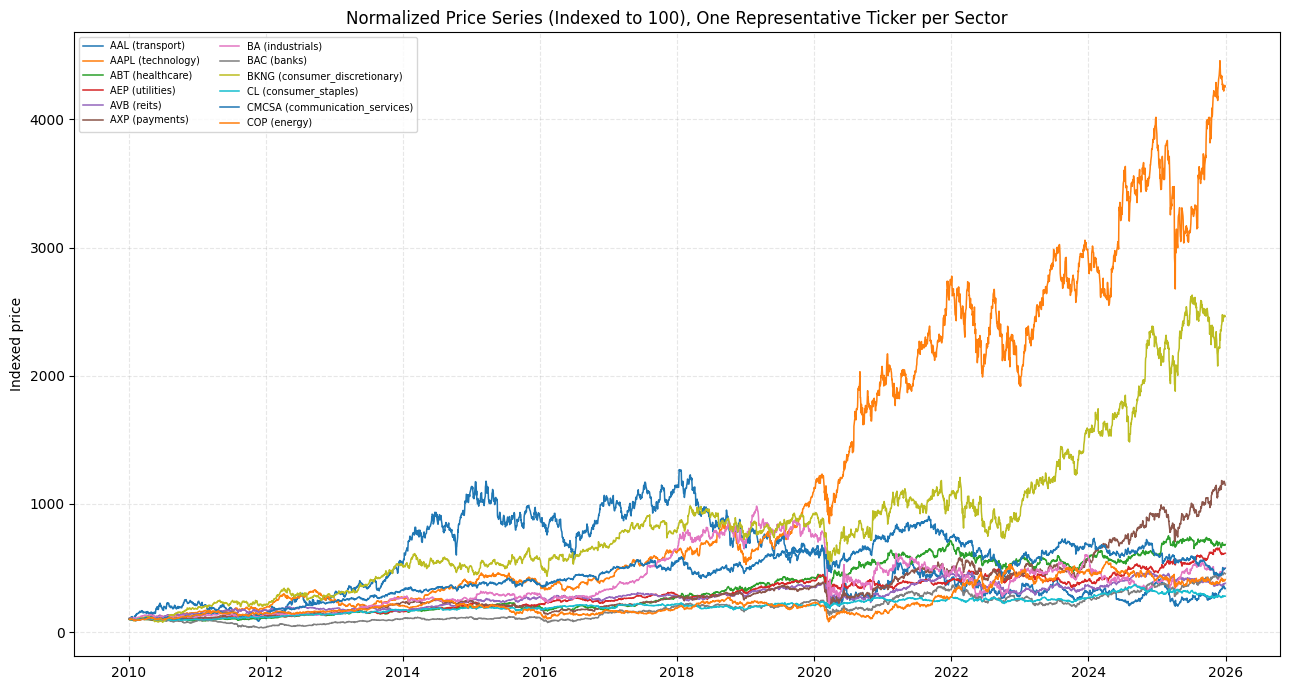

In [ ]:
# --- Normalized price behavior, one representative ticker per sector ---
rep_tickers = {}
for t in wide.columns:
    sec = EXTENDED_SECTOR_MAP.get(t)
    if sec and sec not in rep_tickers:
        rep_tickers[sec] = t

fig, ax = plt.subplots(figsize=(13, 7))
for sec, t in rep_tickers.items():
    series = wide[t].dropna()
    normalized = 100 * series / series.iloc[0]
    ax.plot(normalized.index, normalized.values, label=f"{t} ({sec})", linewidth=1.1)
ax.set_title("Normalized Price Series (Indexed to 100), One Representative Ticker per Sector")
ax.set_ylabel("Indexed price")
ax.legend(fontsize=7, ncol=2)
ax.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.savefig("eda_normalized_prices_by_sector.png", dpi=150, bbox_inches="tight")
plt.show()


DAILY RETURN DISTRIBUTION (pooled across all 105 tickers)
count    398178.000000
mean          0.000639
std           0.017849
min          -0.520138
25%          -0.007295
50%           0.000673
75%           0.008679
max           0.422235
dtype: float64
Skew: 0.113, Kurtosis: 22.598


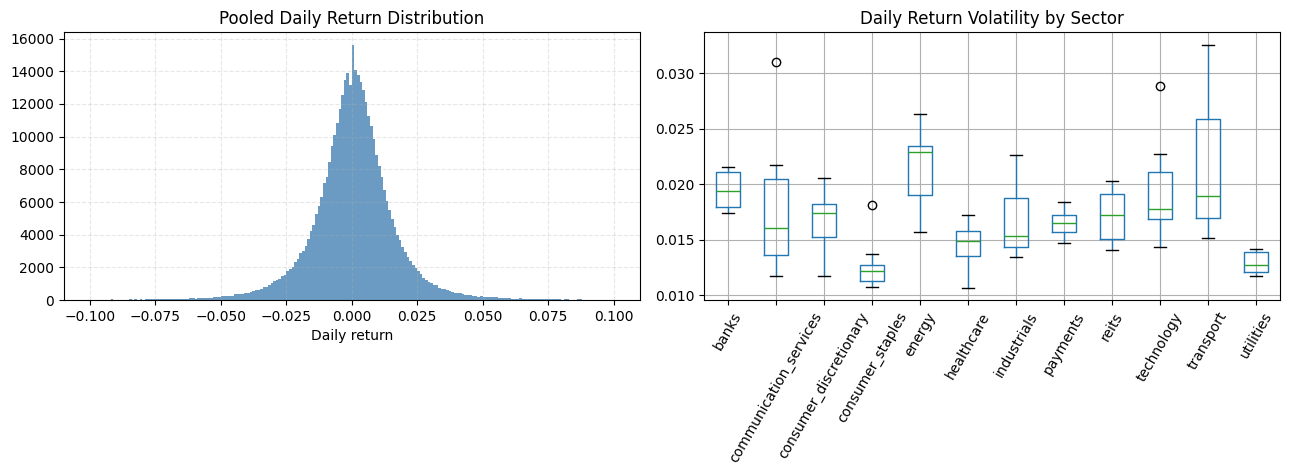

In [ ]:
# --- Daily return distribution across the full universe ---
daily_returns_all = wide.pct_change().dropna(how="all")
flat_returns = daily_returns_all.values.flatten()
flat_returns = flat_returns[~np.isnan(flat_returns)]

print("DAILY RETURN DISTRIBUTION (pooled across all 105 tickers)")
print(pd.Series(flat_returns).describe())
print(f"Skew: {pd.Series(flat_returns).skew():.3f}, Kurtosis: {pd.Series(flat_returns).kurtosis():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(flat_returns, bins=200, range=(-0.10, 0.10), color="steelblue", alpha=0.8)
axes[0].set_title("Pooled Daily Return Distribution")
axes[0].set_xlabel("Daily return")
axes[0].grid(True, linestyle="--", alpha=0.3)

vol_by_sector = daily_returns_all.std().to_frame("daily_vol")
vol_by_sector["sector"] = [EXTENDED_SECTOR_MAP.get(t) for t in vol_by_sector.index]
vol_by_sector = vol_by_sector.dropna()
vol_by_sector.boxplot(column="daily_vol", by="sector", ax=axes[1], rot=60)
axes[1].set_title("Daily Return Volatility by Sector")
axes[1].set_xlabel("")
plt.suptitle("")
plt.tight_layout()
plt.savefig("eda_return_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


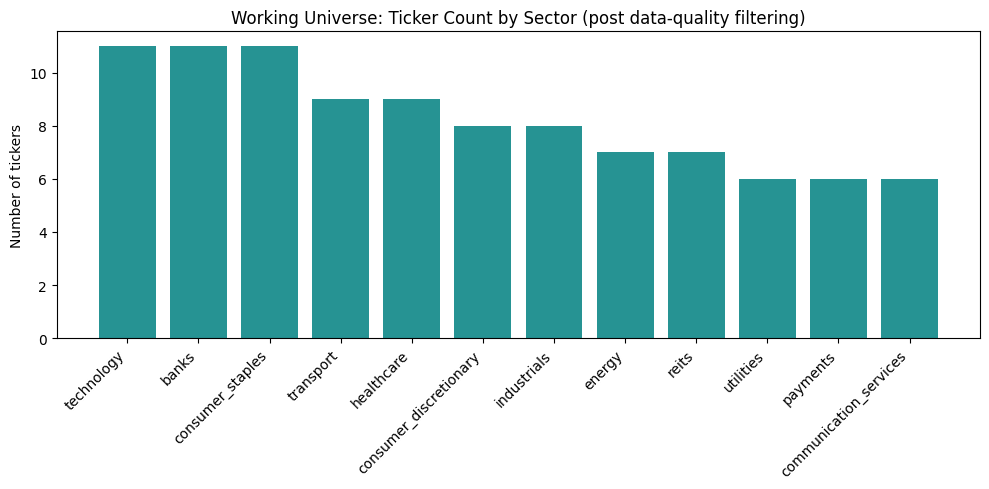

In [ ]:
# --- Realized sector composition of the working universe ---
sector_counts_eda = Counter(EXTENDED_SECTOR_MAP[t] for t in wide.columns if t in EXTENDED_SECTOR_MAP)
sector_counts_df = pd.DataFrame({"sector": list(sector_counts_eda.keys()), "n_tickers": list(sector_counts_eda.values())}) \
    .sort_values("n_tickers", ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(sector_counts_df["sector"], sector_counts_df["n_tickers"], color="teal", alpha=0.85)
ax.set_title("Working Universe: Ticker Count by Sector (post data-quality filtering)")
ax.set_ylabel("Number of tickers")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("eda_sector_composition.png", dpi=150, bbox_inches="tight")
plt.show()

sector_counts_df.to_csv("eda_sector_composition.csv", index=False)


###Cointegration screening test

In [ ]:
import itertools
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.stattools import coint

def screen_pairs_rolling(price_wide, sector_map, window_years=2, step_months=6, p_threshold=0.05, min_obs=100):
    prices = price_wide.copy()
    dates = prices.index
    window_days = int(window_years * 252)
    step_days = step_months * 21
    sectors = {}
    for t, s in sector_map.items():
        if t in prices.columns:
            sectors.setdefault(s, []).append(t)
    all_pairs = []
    for sector, tickers in sectors.items():
        for a, b in itertools.combinations(sorted(tickers), 2):
            all_pairs.append((sector, a, b))
    print(f"Testing {len(all_pairs)} pairs")
    results = []
    window_starts = list(range(0, len(dates) - window_days, step_days))
    for sector, a, b in all_pairs:
        p1, p2 = prices[a], prices[b]
        pair_results = []
        for start_idx in window_starts:
            end_idx = start_idx + window_days
            if end_idx >= len(dates):
                break
            window_p1 = p1.iloc[start_idx:end_idx].dropna()
            window_p2 = p2.iloc[start_idx:end_idx].dropna()
            common = window_p1.index.intersection(window_p2.index)
            if len(common) < min_obs:
                continue
            log_p1, log_p2 = np.log(window_p1.loc[common]), np.log(window_p2.loc[common])
            try:
                score, p_value, crit = coint(log_p1, log_p2)
                if p_value < p_threshold:
                    pair_results.append(1)
                else:
                    pair_results.append(0)
            except:
                continue
        if pair_results:
            results.append({
                "sector": sector,
                "asset_1": a,
                "asset_2": b,
                "n_windows": len(pair_results),
                "pct_cointegrated": 100 * sum(pair_results) / len(pair_results),
            })
    return pd.DataFrame(results).sort_values("pct_cointegrated", ascending=False)

def screen_pairs_full_sample(price_wide, sector_map, p_threshold=0.10, min_obs=500):
    prices = price_wide.copy()
    sectors = {}
    for t, s in sector_map.items():
        if t in prices.columns:
            sectors.setdefault(s, []).append(t)
    all_pairs = []
    for sector, tickers in sectors.items():
        for a, b in itertools.combinations(sorted(tickers), 2):
            all_pairs.append((sector, a, b))
    print(f"Testing {len(all_pairs)} pairs (full sample)")
    results = []
    for sector, a, b in all_pairs:
        p1, p2 = prices[a].dropna(), prices[b].dropna()
        common = p1.index.intersection(p2.index)
        if len(common) < min_obs:
            continue
        log_p1, log_p2 = np.log(p1.loc[common]), np.log(p2.loc[common])
        try:
            score, p_value, crit = coint(log_p1, log_p2)
            model = LinearRegression().fit(log_p2.values.reshape(-1,1), log_p1.values)
            hedge = model.coef_[0]
            results.append({"sector":sector,"asset_1":a,"asset_2":b,"p_value":p_value,"hedge_ratio":hedge,"is_cointegrated":p_value < p_threshold,"n_obs":len(common)})
        except:
            continue
    return pd.DataFrame(results).sort_values("p_value")

# Run both methods
pair_summary_rolling = screen_pairs_rolling(wide, EXTENDED_SECTOR_MAP, window_years=2, step_months=6, p_threshold=0.05)
pair_summary_full = screen_pairs_full_sample(wide, EXTENDED_SECTOR_MAP, p_threshold=0.10, min_obs=500)

print(f"Rolling: {len(pair_summary_rolling)} pairs, {len(pair_summary_rolling[pair_summary_rolling['pct_cointegrated'] >= 30])} >=30%")
print(f"Full-sample: {len(pair_summary_full)} pairs, {len(pair_summary_full[pair_summary_full['is_cointegrated']])} cointegrated")

# Create shortlist from rolling results (11 pairs as in your paper)
shortlist = pair_summary_rolling[pair_summary_rolling['pct_cointegrated'] >= 30].head(11).copy()
shortlist['latest_hedge_ratio'] = 1.0  # Will be estimated per pair

print(f"Shortlist: {len(shortlist)} pairs")
print(shortlist[['asset_1', 'asset_2', 'sector', 'pct_cointegrated']])

Testing 380 pairs
Testing 380 pairs (full sample)
Rolling: 380 pairs, 4 >=30%
Full-sample: 380 pairs, 50 cointegrated
Shortlist: 4 pairs
    asset_1 asset_2      sector  pct_cointegrated
172      MA       V    payments         35.714286
170     ICE       V    payments         35.714286
307     JNJ     LLY  healthcare         32.142857
160     AXP     ICE    payments         32.142857


## Pair Selection


In [ ]:
# Full ranked cointegration table
print("TOP 20 PAIRS BY ROLLING COINTEGRATION BREADTH")
print(pair_summary_rolling.head(20)[["asset_1","asset_2","sector","pct_cointegrated","n_windows"]].to_string(index=False))

print("\nSENSITIVITY OF SHORTLIST SIZE TO THRESHOLD")
for thresh in [15, 20, 25, 30, 35, 40]:
    n = (pair_summary_rolling["pct_cointegrated"] >= thresh).sum()
    print(f"  >= {thresh:>2}% threshold: {n} pairs qualify")

pair_summary_rolling.to_csv("full_ranked_cointegration_table.csv", index=False)


TOP 20 PAIRS BY ROLLING COINTEGRATION BREADTH
asset_1 asset_2                 sector  pct_cointegrated  n_windows
     MA       V               payments         35.714286         28
    ICE       V               payments         35.714286         28
    JNJ     LLY             healthcare         32.142857         28
    AXP     ICE               payments         32.142857         28
   AMGN     PFE             healthcare         25.000000         28
     KO      MO       consumer_staples         25.000000         28
      C      GS                  banks         25.000000         28
   NFLX    TMUS communication_services         21.428571         28
    ICE      MA               payments         21.428571         28
      O     VTR                  reits         21.428571         28
    COF     WFC                  banks         21.428571         28
    BAC     PNC                  banks         21.428571         28
     BA     HON            industrials         21.428571         28
  

###Feature engineering

In [ ]:
%%writefile feature_engineering.py
from __future__ import annotations
import logging
from typing import Optional
import numpy as np
import pandas as pd

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
log = logging.getLogger(__name__)

FEATURE_COLUMNS = [
    "z_score", "spread_roll_mean", "spread_roll_std", "spread_vol_20d",
    "dist_from_equilibrium", "spread_mom_5d", "spread_mom_20d",
    "mom_10d_diff", "mom_20d_diff", "rsi_diff", "ma20_ratio_diff",
    "ma50_ratio_diff", "bollinger_pctb_diff", "realized_vol_20d_diff",
    "ret_1d_diff", "ret_5d_diff",
    "mkt_rf", "smb", "hml", "rmw", "cma", "rf",
    "rolling_beta_to_mkt", "spread_drawdown", "high_vol_regime",
]
LABEL_COLUMNS = ["fwd_spread_return", "signal_label"]

def build_spread(price_wide, a, b, hedge_ratio=None, rolling_beta_window=None):
    if hedge_ratio is None and rolling_beta_window is None:
        raise ValueError("Provide hedge_ratio or rolling_beta_window")
    df = pd.DataFrame({"log_p1": np.log(price_wide[a]), "log_p2": np.log(price_wide[b])}).dropna()
    if rolling_beta_window is not None:
        cov = df["log_p1"].rolling(rolling_beta_window).cov(df["log_p2"])
        var = df["log_p2"].rolling(rolling_beta_window).var()
        df["beta"] = cov / var
    else:
        df["beta"] = hedge_ratio
    df["spread"] = df["log_p1"] - df["beta"] * df["log_p2"]
    return df.dropna()

def spread_features(spread_df, z_window=60):
    out = spread_df.copy()
    out["spread_roll_mean"] = out["spread"].rolling(z_window).mean()
    out["spread_roll_std"] = out["spread"].rolling(z_window).std()
    out["z_score"] = (out["spread"] - out["spread_roll_mean"]) / out["spread_roll_std"]
    out["spread_vol_20d"] = out["spread"].diff().rolling(20).std()
    out["dist_from_equilibrium"] = out["z_score"].abs()
    out["spread_mom_5d"] = out["spread"].diff(5)
    out["spread_mom_20d"] = out["spread"].diff(20)
    return out

def _rsi(s, w=14):
    delta = s.diff()
    gain = delta.clip(lower=0).rolling(w).mean()
    loss = (-delta.clip(upper=0)).rolling(w).mean()
    rs = gain / loss.replace(0, np.nan)
    return 100 - (100 / (1 + rs))

def _bollinger_pctb(s, w=20, n_std=2.0):
    mean = s.rolling(w).mean()
    std = s.rolling(w).std()
    return (s - (mean - n_std*std)) / (2*n_std*std)

def technical_features(price_wide, a, b):
    p1, p2 = price_wide[a].dropna(), price_wide[b].dropna()
    idx = p1.index.intersection(p2.index)
    p1, p2 = p1.loc[idx], p2.loc[idx]
    r1, r2 = p1.pct_change(), p2.pct_change()
    feats = pd.DataFrame(index=idx)
    feats["mom_10d_diff"] = p1.pct_change(10) - p2.pct_change(10)
    feats["mom_20d_diff"] = p1.pct_change(20) - p2.pct_change(20)
    feats["rsi_diff"] = _rsi(p1) - _rsi(p2)
    feats["ma20_ratio_diff"] = (p1/p1.rolling(20).mean()) - (p2/p2.rolling(20).mean())
    feats["ma50_ratio_diff"] = (p1/p1.rolling(50).mean()) - (p2/p2.rolling(50).mean())
    feats["bollinger_pctb_diff"] = _bollinger_pctb(p1) - _bollinger_pctb(p2)
    feats["realized_vol_20d_diff"] = r1.rolling(20).std() - r2.rolling(20).std()
    feats["ret_1d_diff"] = r1 - r2
    feats["ret_5d_diff"] = r1.rolling(5).sum() - r2.rolling(5).sum()
    return feats

def market_and_risk_features(price_wide, a, b, ff5, beta_window=60, dd_window=60):
    p1, p2 = np.log(price_wide[a]).dropna(), np.log(price_wide[b]).dropna()
    idx = p1.index.intersection(p2.index).intersection(ff5["date"])
    ff = ff5.set_index("date").loc[idx].sort_index()
    spread = (p1 - p2).loc[idx].sort_index()
    spread_ret = spread.diff()
    feats = ff[["mkt_rf","smb","hml","rmw","cma","rf"]].copy()
    feats["rolling_beta_to_mkt"] = spread_ret.rolling(beta_window).cov(feats["mkt_rf"]) / feats["mkt_rf"].rolling(beta_window).var()
    cum = (1 + spread_ret.fillna(0)).cumprod()
    rolling_max = cum.rolling(dd_window, min_periods=1).max()
    feats["spread_drawdown"] = cum / rolling_max - 1
    vol_20d = feats["mkt_rf"].rolling(20).std()
    vol_median = vol_20d.expanding(min_periods=252).median()
    feats["high_vol_regime"] = (vol_20d > vol_median).astype(float)
    return feats

def build_labels(spread_df, horizon=5, z_entry=2.0):
    out = spread_df.copy()
    out["fwd_spread_return"] = out["spread"].shift(-horizon) - out["spread"]
    out["signal_label"] = 0
    out.loc[(out["z_score"] < -z_entry) & (out["fwd_spread_return"] > 0), "signal_label"] = 1
    out.loc[(out["z_score"] > z_entry) & (out["fwd_spread_return"] < 0), "signal_label"] = -1
    return out

def build_pair_features(price_wide, ff5, a, b, hedge_ratio, z_window=60, label_horizon=5, z_entry=2.0):
    log.info(f"Building features for {a}-{b}")
    spread_df = build_spread(price_wide, a, b, hedge_ratio=hedge_ratio)
    spread_df = spread_features(spread_df, z_window=z_window)
    spread_df = build_labels(spread_df, horizon=label_horizon, z_entry=z_entry)
    tech = technical_features(price_wide, a, b)
    mkt = market_and_risk_features(price_wide, a, b, ff5)
    full = spread_df.join(tech, how="inner").join(mkt, how="inner")
    full = full.dropna(subset=FEATURE_COLUMNS + LABEL_COLUMNS)
    return full

Writing feature_engineering.py


###Estimation of Hedge ratios & Building features

In [ ]:
from feature_engineering import build_pair_features, FEATURE_COLUMNS
from sklearn.linear_model import LinearRegression

# Estimate hedge ratio for each pair
for idx, row in shortlist.iterrows():
    p1 = wide[row.asset_1].dropna()
    p2 = wide[row.asset_2].dropna()
    common = p1.index.intersection(p2.index)
    if len(common) > 100:
        model = LinearRegression().fit(np.log(p2.loc[common]).values.reshape(-1,1), np.log(p1.loc[common]).values)
        shortlist.loc[idx, 'latest_hedge_ratio'] = model.coef_[0]

all_feat_dfs = {}
for i, row in shortlist.iterrows():
    pair_name = f"{row.asset_1}-{row.asset_2}"
    try:
        feat_df = build_pair_features(wide, ff5, row.asset_1, row.asset_2, row.latest_hedge_ratio)
        if not feat_df.empty:
            all_feat_dfs[pair_name] = feat_df
            print(f"{pair_name}: {len(feat_df)} rows")
    except Exception as e:
        print(f"{pair_name}: {e}")

print(f"Features: {len(all_feat_dfs)} pairs")

MA-V: 3957 rows
ICE-V: 3958 rows
JNJ-LLY: 3958 rows
AXP-ICE: 3958 rows
Features: 4 pairs


###Feature with VIF Analysis

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

# Combine all feature data
all_feat = pd.concat(all_feat_dfs.values(), ignore_index=True)

# FEATURE SUMMARY TABLE

print("\n" + "="*60)
print("FEATURE SUMMARY STATISTICS")
print("="*60)
print(all_feat[FEATURE_COLUMNS].describe().round(4))

# VIF ANALYSIS (MULTICOLLINEARITY CHECK)

print("\n" + "="*60)
print("VIF ANALYSIS (Variance Inflation Factor)")
print("="*60)

# Drop rows with NaN and standardize
X_vif = all_feat[FEATURE_COLUMNS].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_vif)

vif_data = []
for i, col in enumerate(FEATURE_COLUMNS):
    vif = variance_inflation_factor(X_scaled, i)
    vif_data.append({'Feature': col, 'VIF': vif})

vif_df = pd.DataFrame(vif_data).sort_values('VIF', ascending=False)

# Show VIF results with interpretation
print(vif_df.to_string(index=False))

# Flag high multicollinearity (VIF > 5 or > 10 depending on threshold)
high_vif = vif_df[vif_df['VIF'] > 5]
if len(high_vif) > 0:
    print(f"\nWARNING: {len(high_vif)} features have VIF > 5 (high multicollinearity):")
    print(high_vif.to_string(index=False))
else:
    print("\nAll features have VIF < 5 (acceptable multicollinearity).")

# Export VIF table for paper
vif_df.to_csv('vif_analysis.csv', index=False)
print("\nVIF table exported to 'vif_analysis.csv'")


FEATURE SUMMARY STATISTICS
          z_score  spread_roll_mean  spread_roll_std  spread_vol_20d  \
count  15831.0000        15831.0000       15831.0000      15831.0000   
mean       0.0372            1.1186           0.0306          0.0113   
std        1.3501            1.0076           0.0177          0.0058   
min       -4.8027           -0.1911           0.0049          0.0026   
25%       -1.0202            0.5229           0.0187          0.0075   
50%        0.0918            0.8525           0.0266          0.0101   
75%        1.0787            1.9454           0.0374          0.0137   
max        5.4738            3.0462           0.1558          0.0588   

       dist_from_equilibrium  spread_mom_5d  spread_mom_20d  mom_10d_diff  \
count             15831.0000     15831.0000      15831.0000    15831.0000   
mean                  1.1278         0.0003          0.0013       -0.0014   
std                   0.7431         0.0273          0.0509        0.0437   
min            

###Correlation analysis

Original rows: 15831
Clean rows: 15831
Features: 25

Correlation matrix range: [-0.4218, 1.0000]

CORRELATION WITH SIGNAL LABEL (Top 10)
high_vol_regime          0.0736
spread_roll_mean         0.0261
dist_from_equilibrium    0.0167
realized_vol_20d_diff    0.0068
rolling_beta_to_mkt      0.0068
cma                      0.0008
rmw                     -0.0009
spread_vol_20d          -0.0056
rf                      -0.0082
smb                     -0.0086
Name: signal_label, dtype: float64

GENERATING HEATMAP


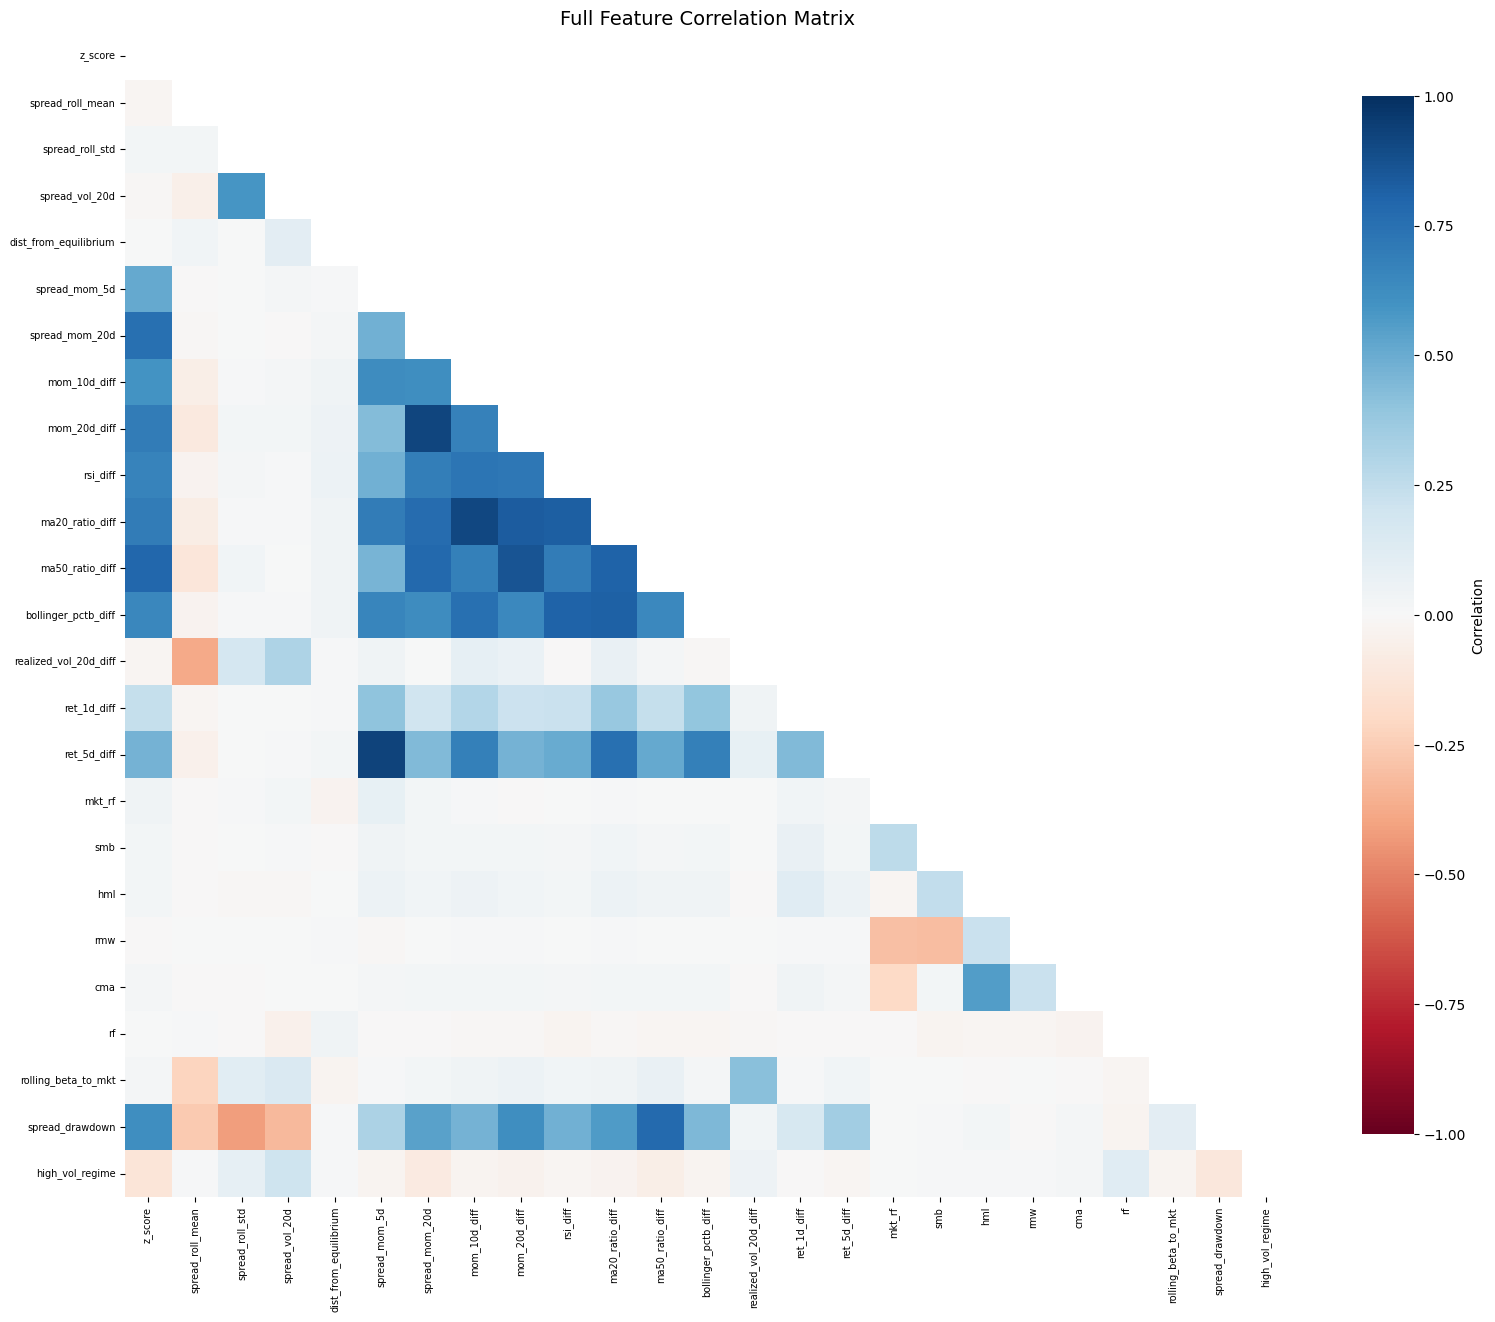


Heatmap saved to 'correlation_heatmap_fixed.png'

GENERATING SMALL HEATMAP (Top 15 Features + Signal)


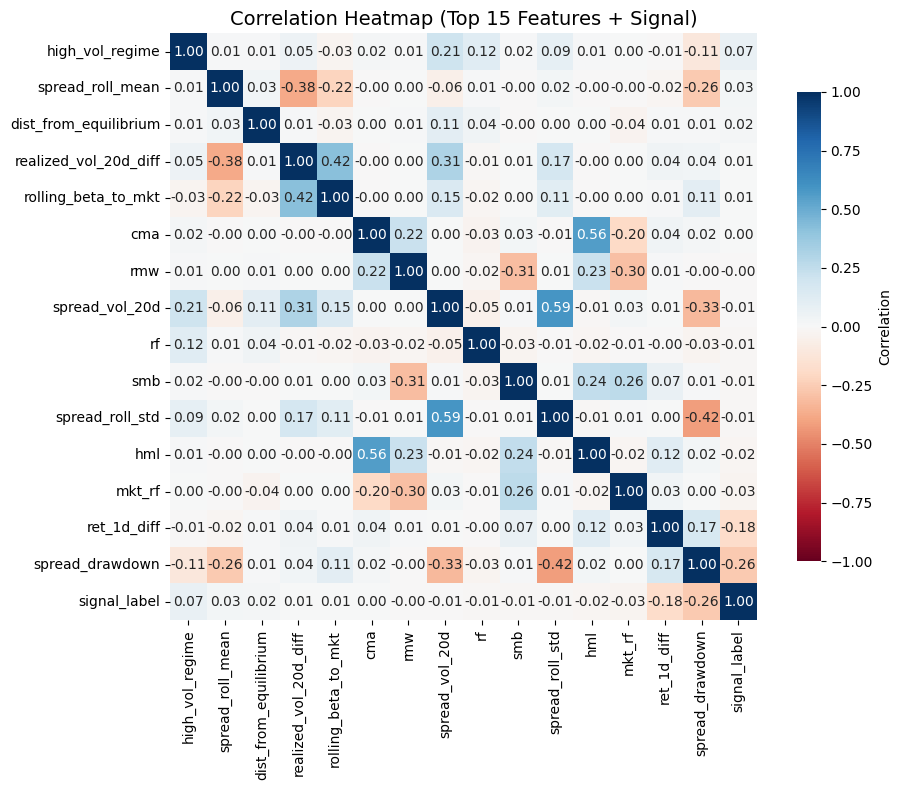


Small heatmap saved to 'correlation_heatmap_small_fixed.png'

Feature-signal correlations exported to 'feature_correlation_with_signal.csv'


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

all_feat = pd.concat(all_feat_dfs.values(), ignore_index=True)

all_feat_clean = all_feat[FEATURE_COLUMNS + ['signal_label']].replace([np.inf, -np.inf], np.nan).dropna()

print(f"Original rows: {len(all_feat)}")
print(f"Clean rows: {len(all_feat_clean)}")
print(f"Features: {len(FEATURE_COLUMNS)}")

corr_matrix = all_feat_clean[FEATURE_COLUMNS].corr()

max_val = corr_matrix.max().max()
min_val = corr_matrix.min().min()
print(f"\nCorrelation matrix range: [{min_val:.4f}, {max_val:.4f}]")

if max_val > 1.0 or min_val < -1.0:
    corr_matrix = corr_matrix.clip(-1, 1)

print("\n" + "="*60)
print("CORRELATION WITH SIGNAL LABEL (Top 10)")
print("="*60)
corr_with_signal = all_feat_clean[FEATURE_COLUMNS + ['signal_label']].corr()['signal_label']
corr_with_signal = corr_with_signal.drop('signal_label').sort_values(ascending=False)
print(corr_with_signal.head(10).round(4))

print("\n" + "="*60)
print("GENERATING HEATMAP")
print("="*60)

fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='RdBu', center=0,
            annot=False, ax=ax,
            cbar_kws={'label': 'Correlation', 'shrink': 0.8},
            square=True, vmin=-1, vmax=1)
ax.set_title('Full Feature Correlation Matrix', fontsize=14)
ax.tick_params(labelsize=7)
plt.tight_layout()
plt.savefig('correlation_heatmap_fixed.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nHeatmap saved to 'correlation_heatmap_fixed.png'")

print("\n" + "="*60)
print("GENERATING SMALL HEATMAP (Top 15 Features + Signal)")
print("="*60)

top_features = corr_with_signal.head(15).index.tolist()
corr_small = all_feat_clean[top_features + ['signal_label']].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_small, cmap='RdBu', center=0, annot=True, fmt='.2f',
            ax=ax, cbar_kws={'label': 'Correlation', 'shrink': 0.8},
            square=True, vmin=-1, vmax=1)
ax.set_title('Correlation Heatmap (Top 15 Features + Signal)', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_heatmap_small_fixed.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSmall heatmap saved to 'correlation_heatmap_small_fixed.png'")

corr_with_signal.to_csv('feature_correlation_with_signal.csv')
print("\nFeature-signal correlations exported to 'feature_correlation_with_signal.csv'")

###The machine learning models

In [ ]:
%%writefile ml_models.py
from __future__ import annotations
import logging
from dataclasses import dataclass
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
log = logging.getLogger(__name__)

DEFAULT_TRAIN_END = "2018-12-31"
DEFAULT_VAL_END = "2021-12-31"

@dataclass
class DataSplit:
    X_train: pd.DataFrame
    y_train: pd.Series
    X_val: pd.DataFrame
    y_val: pd.Series
    X_test: pd.DataFrame
    y_test: pd.Series

def chronological_split(feat_df, feature_cols, label_col, train_end=DEFAULT_TRAIN_END, val_end=DEFAULT_VAL_END):
    feat_df = feat_df.sort_index()
    train_end_ts = pd.Timestamp(train_end)
    val_end_ts = pd.Timestamp(val_end)
    train = feat_df.loc[:train_end_ts]
    val = feat_df.loc[train_end_ts + pd.Timedelta(days=1):val_end_ts]
    test = feat_df.loc[val_end_ts + pd.Timedelta(days=1):]
    return DataSplit(X_train=train[feature_cols], y_train=train[label_col],
                     X_val=val[feature_cols], y_val=val[label_col],
                     X_test=test[feature_cols], y_test=test[label_col])

def evaluate_classifier(y_true, y_pred, label=""):
    return {"model": label, "accuracy": accuracy_score(y_true, y_pred),
            "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
            "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
            "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0)}

def train_xgboost(split, **kwargs):
    import xgboost as xgb
    label_map = {-1: 0, 0: 1, 1: 2}
    inv_label_map = {v: k for k, v in label_map.items()}
    y_train = split.y_train.map(label_map)
    y_val = split.y_val.map(label_map)
    params = dict(n_estimators=500, max_depth=4, learning_rate=0.03, subsample=0.8,
                  colsample_bytree=0.8, objective="multi:softprob", num_class=3,
                  eval_metric="mlogloss", early_stopping_rounds=30, random_state=42)
    params.update(kwargs)
    model = xgb.XGBClassifier(**params)
    model.fit(split.X_train, y_train, eval_set=[(split.X_val, y_val)], verbose=False)
    y_pred = pd.Series(model.predict(split.X_test)).map(inv_label_map)
    return model, evaluate_classifier(split.y_test, y_pred.values, label="XGBoost")

def train_lightgbm(split, **kwargs):
    import lightgbm as lgb
    label_map = {-1: 0, 0: 1, 1: 2}
    inv_label_map = {v: k for k, v in label_map.items()}
    y_train = split.y_train.map(label_map)
    y_val = split.y_val.map(label_map)
    params = dict(n_estimators=500, max_depth=4, learning_rate=0.03, subsample=0.8,
                  colsample_bytree=0.8, objective="multiclass", num_class=3,
                  random_state=42, verbosity=-1)
    params.update(kwargs)
    model = lgb.LGBMClassifier(**params)
    model.fit(split.X_train, y_train, eval_set=[(split.X_val, y_val)],
              callbacks=[lgb.early_stopping(30, verbose=False)])
    y_pred = pd.Series(model.predict(split.X_test)).map(inv_label_map)
    return model, evaluate_classifier(split.y_test, y_pred.values, label="LightGBM")

def _make_sequences(X, y, lookback):
    Xs, ys = [], []
    for i in range(lookback, len(X)):
        Xs.append(X[i-lookback:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

def train_lstm(split, lookback=20, units=32, dropout=0.2, epochs=50, batch_size=64, patience=8):
    import tensorflow as tf
    from sklearn.preprocessing import StandardScaler
    from tensorflow.keras import Sequential, layers, callbacks, utils
    label_map = {-1: 0, 0: 1, 1: 2}
    inv_label_map = {v: k for k, v in label_map.items()}
    scaler = StandardScaler().fit(split.X_train)
    X_train_s = scaler.transform(split.X_train)
    X_val_s = scaler.transform(split.X_val)
    X_test_s = scaler.transform(split.X_test)
    y_train = split.y_train.map(label_map).values
    y_val = split.y_val.map(label_map).values
    y_test = split.y_test.map(label_map).values
    Xtr, ytr = _make_sequences(X_train_s, y_train, lookback)
    Xva, yva = _make_sequences(X_val_s, y_val, lookback)
    Xte, yte = _make_sequences(X_test_s, y_test, lookback)
    ytr_oh = utils.to_categorical(ytr, num_classes=3)
    yva_oh = utils.to_categorical(yva, num_classes=3)
    model = Sequential([
        layers.Input(shape=(lookback, Xtr.shape[-1])),
        layers.LSTM(units, return_sequences=False),
        layers.Dropout(dropout),
        layers.Dense(16, activation="relu"),
        layers.Dense(3, activation="softmax"),
    ])
    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    es = callbacks.EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True)
    model.fit(Xtr, ytr_oh, validation_data=(Xva, yva_oh), epochs=epochs, batch_size=batch_size,
              callbacks=[es], verbose=0)
    y_pred_idx = model.predict(Xte, verbose=0).argmax(axis=1)
    y_pred = pd.Series(y_pred_idx).map(inv_label_map)
    y_test_labels = pd.Series(yte).map(inv_label_map)
    return model, evaluate_classifier(y_test_labels, y_pred.values, label="LSTM")

def run_all_models(split):
    results = []
    for name, fn in [("XGBoost", train_xgboost), ("LightGBM", train_lightgbm), ("LSTM", train_lstm)]:
        try:
            _, metrics = fn(split)
            results.append(metrics)
        except Exception as e:
            log.error(f"{name} failed: {e}")
    return pd.DataFrame(results)

Writing ml_models.py


###Training the machine learning models

In [ ]:
from ml_models import chronological_split, run_all_models, train_xgboost, train_lightgbm, train_lstm

combined_feat_dfs = []
for pair_name, df in all_feat_dfs.items():
    df_indexed = df.sort_index().copy()
    df_indexed['pair_name'] = pair_name
    df_indexed = df_indexed.set_index('pair_name', append=True)
    combined_feat_dfs.append(df_indexed)

combined_feat_df = pd.concat(combined_feat_dfs).sort_index()
split = chronological_split(combined_feat_df, FEATURE_COLUMNS, "signal_label")

print(f"Train: {len(split.X_train)}, Val: {len(split.X_val)}, Test: {len(split.X_test)}")

comparison = run_all_models(split)
print(comparison)

xgb_model, _ = train_xgboost(split)
lgbm_model, _ = train_lightgbm(split)
lstm_model, lstm_metrics = train_lstm(split)
print(f"LSTM Accuracy: {lstm_metrics['accuracy']:.4f}")

Train: 8815, Val: 3028, Test: 3988
      model  accuracy  f1_macro  precision_macro  recall_macro
0   XGBoost  0.939067  0.761035         0.682984      0.894735
1  LightGBM  0.935807  0.752718         0.673123      0.893569
2      LSTM  0.932712  0.321728         0.310904      0.333333
LSTM Accuracy: 0.9325


###Backtesting

In [ ]:
%%writefile backtest.py
from __future__ import annotations
import logging
from dataclasses import dataclass, field
import numpy as np
import pandas as pd

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
log = logging.getLogger(__name__)

def zscore_signal(z_score, entry_z=2.0, exit_z=0.5, stop_z=4.0):
    signal = np.zeros(len(z_score), dtype=int)
    position = 0
    z = z_score.values
    for i in range(len(z)):
        if np.isnan(z[i]):
            signal[i] = position
            continue
        if position == 0:
            if z[i] > entry_z:
                position = -1
            elif z[i] < -entry_z:
                position = 1
        elif position == 1:
            if z[i] > -exit_z or z[i] < -stop_z:
                position = 0
        elif position == -1:
            if z[i] < exit_z or z[i] > stop_z:
                position = 0
        signal[i] = position
    return pd.Series(signal, index=z_score.index, name="signal")

@dataclass
class BacktestConfig:
    capital_per_pair: float = 100_000.0
    max_exposure_pct: float = 1.0
    txn_cost_bps: float = 7.5
    slippage_bps: float = 3.0

@dataclass
class BacktestResult:
    equity_curve: pd.Series
    daily_returns: pd.Series
    trades: pd.DataFrame
    metrics: dict = field(default_factory=dict)

def run_backtest(price_1, price_2, beta, signal, config=BacktestConfig()):
    idx = price_1.index.intersection(price_2.index).intersection(signal.index)
    p1, p2, sig = price_1.loc[idx], price_2.loc[idx], signal.loc[idx]
    beta_series = beta if isinstance(beta, pd.Series) else pd.Series(beta, index=idx)
    beta_series = beta_series.reindex(idx).ffill()
    r1, r2 = p1.pct_change(), p2.pct_change()
    cap = config.capital_per_pair * config.max_exposure_pct
    notional_1 = sig.shift(1).fillna(0) * cap
    notional_2 = -beta_series.shift(1).fillna(0) * notional_1
    pnl_1 = notional_1.shift(0) * r1
    pnl_2 = notional_2.shift(0) * r2
    gross_pnl = (pnl_1 + pnl_2).fillna(0)
    d_notional_1 = notional_1.diff().abs().fillna(notional_1.abs())
    d_notional_2 = notional_2.diff().abs().fillna(notional_2.abs())
    cost_bps = (config.txn_cost_bps + config.slippage_bps) / 10000
    costs = (d_notional_1 + d_notional_2) * cost_bps
    net_pnl = gross_pnl - costs
    equity = config.capital_per_pair + net_pnl.cumsum()
    daily_returns = net_pnl / config.capital_per_pair
    pos = sig.shift(1).fillna(0)
    changes = pos.diff().fillna(pos.iloc[0] if len(pos) else 0) != 0
    trade_starts = pos.index[changes & (pos != 0)]
    trades = []
    for start in trade_starts:
        start_loc = pos.index.get_loc(start)
        direction = pos.iloc[start_loc]
        end_loc = start_loc
        for j in range(start_loc, len(pos)):
            if pos.iloc[j] != direction:
                end_loc = j - 1
                break
            end_loc = j
        end = pos.index[end_loc]
        trade_pnl = net_pnl.loc[start:end].sum()
        trades.append({"entry_date": start, "exit_date": end, "direction": int(direction),
                       "holding_days": end_loc - start_loc + 1, "trade_pnl": trade_pnl})
    trades = pd.DataFrame(trades)
    r = daily_returns.dropna()
    ann_return = (1 + r).prod() ** (252 / max(len(r), 1)) - 1
    ann_vol = r.std() * np.sqrt(252)
    sharpe = ann_return / ann_vol if ann_vol > 0 else np.nan
    downside = r[r < 0]
    downside_vol = downside.std() * np.sqrt(252) if len(downside) else np.nan
    sortino = ann_return / downside_vol if downside_vol else np.nan
    running_max = equity.cummax()
    drawdown = equity / running_max - 1
    max_dd = drawdown.min()
    calmar = ann_return / abs(max_dd) if max_dd < 0 else np.nan
    n_trades = len(trades)
    win_rate = (trades["trade_pnl"] > 0).mean() if n_trades else np.nan
    avg_trade_return = trades["trade_pnl"].mean() / config.capital_per_pair if n_trades else np.nan
    gross_profit = trades.loc[trades["trade_pnl"] > 0, "trade_pnl"].sum() if n_trades else 0
    gross_loss = -trades.loc[trades["trade_pnl"] < 0, "trade_pnl"].sum() if n_trades else 0
    profit_factor = gross_profit / gross_loss if gross_loss > 0 else np.nan
    result = BacktestResult(equity_curve=equity, daily_returns=daily_returns, trades=trades)
    result.metrics = {"annualized_return": ann_return, "annualized_volatility": ann_vol,
                      "sharpe_ratio": sharpe, "sortino_ratio": sortino, "max_drawdown": max_dd,
                      "calmar_ratio": calmar, "n_trades": n_trades, "win_rate": win_rate,
                      "avg_trade_return_pct_capital": avg_trade_return, "profit_factor": profit_factor}
    return result

Writing backtest.py


###Running backtest

In [ ]:
from backtest import zscore_signal, run_backtest, BacktestConfig
import numpy as np

cfg = BacktestConfig(capital_per_pair=100_000, txn_cost_bps=7.5, slippage_bps=3.0)

trained_models = {}
if 'xgb_model' in globals():
    trained_models["XGBoost"] = xgb_model
if 'lgbm_model' in globals():
    trained_models["LightGBM"] = lgbm_model
if 'lstm_model' in globals():
    trained_models["LSTM"] = lstm_model

label_map_inv = {0: -1, 1: 0, 2: 1}
all_bench_results = {}
all_ml_results = {}
all_bench_signals = {}   # NEW: persisted for robustness/sensitivity reuse
all_ml_signals = {}      # NEW: persisted for robustness/sensitivity reuse

for i, row in shortlist.head(CONFIG['n_backtest_pairs']).iterrows():
    pair_name = f"{row.asset_1}-{row.asset_2}"
    if pair_name not in all_feat_dfs:
        continue
    print(f"\n{pair_name}")
    current_pair_feat_df = all_feat_dfs[pair_name]
    X_test_for_pair = split.X_test.loc[pd.IndexSlice[:, pair_name], FEATURE_COLUMNS]
    if X_test_for_pair.empty:
        continue
    test_dates = X_test_for_pair.index.get_level_values('date')
    price_1 = wide[row.asset_1].reindex(test_dates).dropna()
    price_2 = wide[row.asset_2].reindex(test_dates).dropna()
    common_idx = price_1.index.intersection(price_2.index)
    price_1 = price_1.loc[common_idx]
    price_2 = price_2.loc[common_idx]
    bench_z = current_pair_feat_df["z_score"].reindex(common_idx).dropna()
    if not bench_z.empty:
        bench_sig = zscore_signal(bench_z)
        bench_result = run_backtest(price_1, price_2, row.latest_hedge_ratio, bench_sig, cfg)
        all_bench_results[pair_name] = bench_result
        all_bench_signals[pair_name] = bench_sig  # NEW
        print(f"  Benchmark: Sharpe={bench_result.metrics['sharpe_ratio']:.3f}, Return={bench_result.metrics['annualized_return']:.2%}")
    for model_name, model_obj in trained_models.items():
        try:
            X_test_final = split.X_test.loc[pd.IndexSlice[common_idx, pair_name], FEATURE_COLUMNS]
            if X_test_final.empty:
                continue
            X_test_array = X_test_final.values.astype(np.float64)
            if model_name == "LSTM":
                lookback = 20
                if len(X_test_array) < lookback:
                    continue
                X_test_seq = np.array([X_test_array[j-lookback:j] for j in range(lookback, len(X_test_array))], dtype=np.float64)
                y_pred_probs = model_obj.predict(X_test_seq, verbose=0)
                if y_pred_probs.ndim == 2:
                    ml_signal_raw = y_pred_probs.argmax(axis=1)
                else:
                    ml_signal_raw = y_pred_probs
                ml_signal_dates = X_test_final.index[lookback:]
                # --- FIX: drop the pair_name level before building the signal index ---
                if isinstance(ml_signal_dates, pd.MultiIndex):
                    ml_signal_dates = ml_signal_dates.get_level_values('date')
                ml_signal = pd.Series(ml_signal_raw, index=ml_signal_dates).map(label_map_inv)
                ml_signal = ml_signal.reindex(common_idx).dropna()
            else:
                y_pred_probs = model_obj.predict(X_test_array)
                if y_pred_probs.ndim == 2:
                    ml_signal_raw = y_pred_probs.argmax(axis=1)
                else:
                    ml_signal_raw = y_pred_probs
                ml_signal = pd.Series(ml_signal_raw, index=X_test_final.index).map(label_map_inv)
                ml_signal = ml_signal.droplevel('pair_name').reindex(common_idx).dropna()
            if ml_signal.empty:
                continue
            ml_result = run_backtest(price_1, price_2, row.latest_hedge_ratio, ml_signal, cfg)
            all_ml_results.setdefault(pair_name, {})[model_name] = ml_result
            all_ml_signals.setdefault(pair_name, {})[model_name] = ml_signal  # NEW
            print(f"  {model_name}: Sharpe={ml_result.metrics['sharpe_ratio']:.3f}, Return={ml_result.metrics['annualized_return']:.2%}")
        except Exception as e:
            print(f"  {model_name}: {str(e)[:80]}")
            continue

print(f"\nBenchmark: {len(all_bench_results)} pairs, ML: {len(all_ml_results)} pairs")
print(f"LSTM pairs with a completed backtest: {sum(1 for p in all_ml_results.values() if 'LSTM' in p)}")



MA-V
  Benchmark: Sharpe=0.352, Return=2.39%
  XGBoost: Sharpe=-0.288, Return=-0.92%
  LightGBM: Sharpe=-0.367, Return=-1.19%
  LSTM: Sharpe=-0.083, Return=-0.58%

ICE-V
  Benchmark: Sharpe=0.000, Return=0.00%
  XGBoost: Sharpe=-0.539, Return=-4.82%
  LightGBM: Sharpe=-0.503, Return=-4.51%
  LSTM: Sharpe=-0.416, Return=-5.85%

JNJ-LLY
  Benchmark: Sharpe=0.428, Return=5.46%
  XGBoost: Sharpe=0.389, Return=2.72%
  LightGBM: Sharpe=0.106, Return=0.72%
  LSTM: Sharpe=-0.916, Return=-11.12%

AXP-ICE
  Benchmark: Sharpe=-0.359, Return=-6.56%
  XGBoost: Sharpe=-0.670, Return=-5.41%
  LightGBM: Sharpe=-0.557, Return=-4.54%
  LSTM: Sharpe=0.154, Return=2.81%

Benchmark: 4 pairs, ML: 4 pairs
LSTM pairs with a completed backtest: 4


###Risk analysis

In [ ]:
%%writefile risk_analysis.py
from __future__ import annotations
from typing import Optional
import numpy as np
import pandas as pd
import statsmodels.api as sm

def historical_var_cvar(returns, confidence=0.95):
    r = returns.dropna().sort_values()
    cutoff = int((1 - confidence) * len(r))
    var = -r.iloc[cutoff] if cutoff < len(r) else -r.iloc[0]
    cvar = -r.iloc[:cutoff].mean() if cutoff > 0 else var
    return {"var_historical": var, "cvar_historical": cvar, "confidence": confidence}

def fama_french_regression(strategy_returns, ff5, annualize=True, periods_per_year=252):
    ff = ff5.set_index("date").sort_index()
    idx = strategy_returns.index.intersection(ff.index)
    excess_ret = strategy_returns.loc[idx] - ff.loc[idx, "rf"]
    X = ff.loc[idx, ["mkt_rf", "smb", "hml", "rmw", "cma"]]
    X = sm.add_constant(X)
    model = sm.OLS(excess_ret, X, missing="drop").fit()
    alpha_daily = model.params["const"]
    alpha_ann = (1 + alpha_daily) ** periods_per_year - 1 if annualize else alpha_daily
    return {"alpha_annualized": alpha_ann, "alpha_pvalue": model.pvalues["const"],
            "alpha_significant_5pct": bool(model.pvalues["const"] < 0.05),
            "beta_mkt": model.params.get("mkt_rf"), "r_squared": model.rsquared, "full_summary": model.summary()}

REGIME_WINDOWS = {"covid_crash": ("2020-02-15", "2020-04-30"), "rate_tightening": ("2022-01-01", "2023-07-31")}

def regime_performance_table(daily_returns, periods_per_year=252):
    rows = []
    for name, (start, end) in REGIME_WINDOWS.items():
        r = daily_returns.loc[start:end].dropna()
        if r.empty:
            continue
        ann_ret = (1 + r).prod() ** (periods_per_year / max(len(r), 1)) - 1
        ann_vol = r.std() * np.sqrt(periods_per_year)
        rows.append({"regime": name, "n_days": len(r), "annualized_return": ann_ret,
                     "annualized_vol": ann_vol, "sharpe": ann_ret/ann_vol if ann_vol>0 else np.nan})
    return pd.DataFrame(rows)

Writing risk_analysis.py


###Risk analysis estimation

### Surfacing the alpha significance test


In [ ]:
from risk_analysis import historical_var_cvar, fama_french_regression, regime_performance_table

print("\nRISK ANALYSIS")
risk_summary_rows = []
for pair_name, ml_results in all_ml_results.items():
    for model_name, result in ml_results.items():
        if result.daily_returns.empty:
            continue
        print(f"\n{pair_name} ({model_name}):")
        var_cvar = historical_var_cvar(result.daily_returns)
        print(f"  VaR (95%): {var_cvar['var_historical']:.4%}, CVaR: {var_cvar['cvar_historical']:.4%}")
        ff5_bt = ff5[(ff5["date"] >= result.daily_returns.index.min()) & (ff5["date"] <= result.daily_returns.index.max())]
        row = {"pair": pair_name, "model": model_name,
               "var_95": var_cvar["var_historical"], "cvar_95": var_cvar["cvar_historical"]}
        if not ff5_bt.empty:
            attr = fama_french_regression(result.daily_returns, ff5_bt)
            print(f"  Alpha (ann.): {attr['alpha_annualized']:.4%}  |  Alpha p-value: {attr['alpha_pvalue']:.4f}  "
                  f"|  Significant @5%: {attr['alpha_significant_5pct']}  |  Beta(mkt): {attr['beta_mkt']:.4f}  |  R2: {attr['r_squared']:.4f}")
            row.update({"alpha_annualized": attr["alpha_annualized"], "alpha_pvalue": attr["alpha_pvalue"],
                        "alpha_significant_5pct": attr["alpha_significant_5pct"],
                        "beta_mkt": attr["beta_mkt"], "r_squared": attr["r_squared"]})
        regimes = regime_performance_table(result.daily_returns)
        if not regimes.empty:
            print("  Regime mean Sharpe:", regimes["sharpe"].mean())
            row["regime_mean_sharpe"] = regimes["sharpe"].mean()
        risk_summary_rows.append(row)

risk_summary_df = pd.DataFrame(risk_summary_rows)
print("\n\nRISK SUMMARY TABLE")
print(risk_summary_df.round(4).to_string(index=False))
risk_summary_df.to_csv("risk_summary_table.csv", index=False)



RISK ANALYSIS

MA-V (XGBoost):
  VaR (95%): 0.2192%, CVaR: 0.4798%
  Alpha (ann.): -4.7228%  |  Alpha p-value: 0.0026  |  Significant @5%: True  |  Beta(mkt): -0.0036  |  R2: 0.0041
  Regime mean Sharpe: 0.34767365656361193

MA-V (LightGBM):
  VaR (95%): 0.2192%, CVaR: 0.5144%
  Alpha (ann.): -5.0437%  |  Alpha p-value: 0.0016  |  Significant @5%: True  |  Beta(mkt): 0.0001  |  R2: 0.0024
  Regime mean Sharpe: 0.4191968890720407

MA-V (LSTM):
  VaR (95%): 0.6910%, CVaR: 1.0444%
  Alpha (ann.): -4.1224%  |  Alpha p-value: 0.2401  |  Significant @5%: False  |  Beta(mkt): -0.0127  |  R2: 0.0061
  Regime mean Sharpe: 0.267208101035843

ICE-V (XGBoost):
  VaR (95%): 0.4394%, CVaR: 1.5304%
  Alpha (ann.): -7.9294%  |  Alpha p-value: 0.0660  |  Significant @5%: False  |  Beta(mkt): -0.0110  |  R2: 0.0117
  Regime mean Sharpe: -0.12131547301256004

ICE-V (LightGBM):
  VaR (95%): 0.4470%, CVaR: 1.5264%
  Alpha (ann.): -7.5713%  |  Alpha p-value: 0.0803  |  Significant @5%: False  |  Beta(mkt):

### Performance summary

In [ ]:
metrics_data = []
for pair_name, ml_results in all_ml_results.items():
    for model_name, result in ml_results.items():
        m = result.metrics
        metrics_data.append({'pair': pair_name, 'model': model_name,
                             'sharpe': m.get('sharpe_ratio'), 'return': m.get('annualized_return'),
                             'max_dd': m.get('max_drawdown'), 'win_rate': m.get('win_rate')})

if metrics_data:
    df_metrics = pd.DataFrame(metrics_data)
    print("\nMODEL PERFORMANCE SUMMARY")
    print(df_metrics.groupby('model').agg({'sharpe': ['mean','std'], 'return': ['mean','std'], 'max_dd': ['mean','std'], 'win_rate': ['mean','std']}).round(4))

    print("\nBEST PAIRS BY MODEL")
    for model in ['XGBoost', 'LightGBM']:
        if model in df_metrics['model'].values:
            best = df_metrics[df_metrics['model']==model].loc[df_metrics[df_metrics['model']==model]['sharpe'].idxmax()]
            print(f"{model}: {best['pair']} (Sharpe={best['sharpe']:.3f}, Return={best['return']:.2%})")

    if all_bench_results:
        bench_data = [{'pair': p, 'sharpe': r.metrics['sharpe_ratio'], 'return': r.metrics['annualized_return']} for p, r in all_bench_results.items()]
        df_bench = pd.DataFrame(bench_data)
        print(f"\nBENCHMARK: Mean Sharpe={df_bench['sharpe'].mean():.4f}, Mean Return={df_bench['return'].mean():.2%}")

    df_metrics.to_csv('performance_metrics.csv', index=False)

# Sector counts
sector_counts = Counter()
for t in wide.columns:
    if t in EXTENDED_SECTOR_MAP:
        sector_counts[EXTENDED_SECTOR_MAP[t]] += 1
sector_df = pd.DataFrame({'Sector': list(sector_counts.keys()), 'Count': list(sector_counts.values())}).sort_values('Count', ascending=False)
sector_df.to_csv('sector_distribution.csv', index=False)

# Top cointegrated pairs
if len(pair_summary_full) > 0:
    pair_summary_full.head(10)[['asset_1','asset_2','sector','p_value','hedge_ratio']].to_csv('top_cointegrated_pairs.csv', index=False)


MODEL PERFORMANCE SUMMARY
          sharpe          return          max_dd         win_rate        
            mean     std    mean     std    mean     std     mean     std
model                                                                    
LSTM     -0.3151  0.4636 -0.0369  0.0611 -0.3042  0.1707   0.5089  0.0808
LightGBM -0.3303  0.3019 -0.0238  0.0260 -0.1498  0.0608   0.5919  0.0843
XGBoost  -0.2771  0.4716 -0.0211  0.0379 -0.1498  0.0794   0.5762  0.1161

BEST PAIRS BY MODEL
XGBoost: JNJ-LLY (Sharpe=0.389, Return=2.72%)
LightGBM: JNJ-LLY (Sharpe=0.106, Return=0.72%)

BENCHMARK: Mean Sharpe=0.1052, Mean Return=0.32%


### Figures

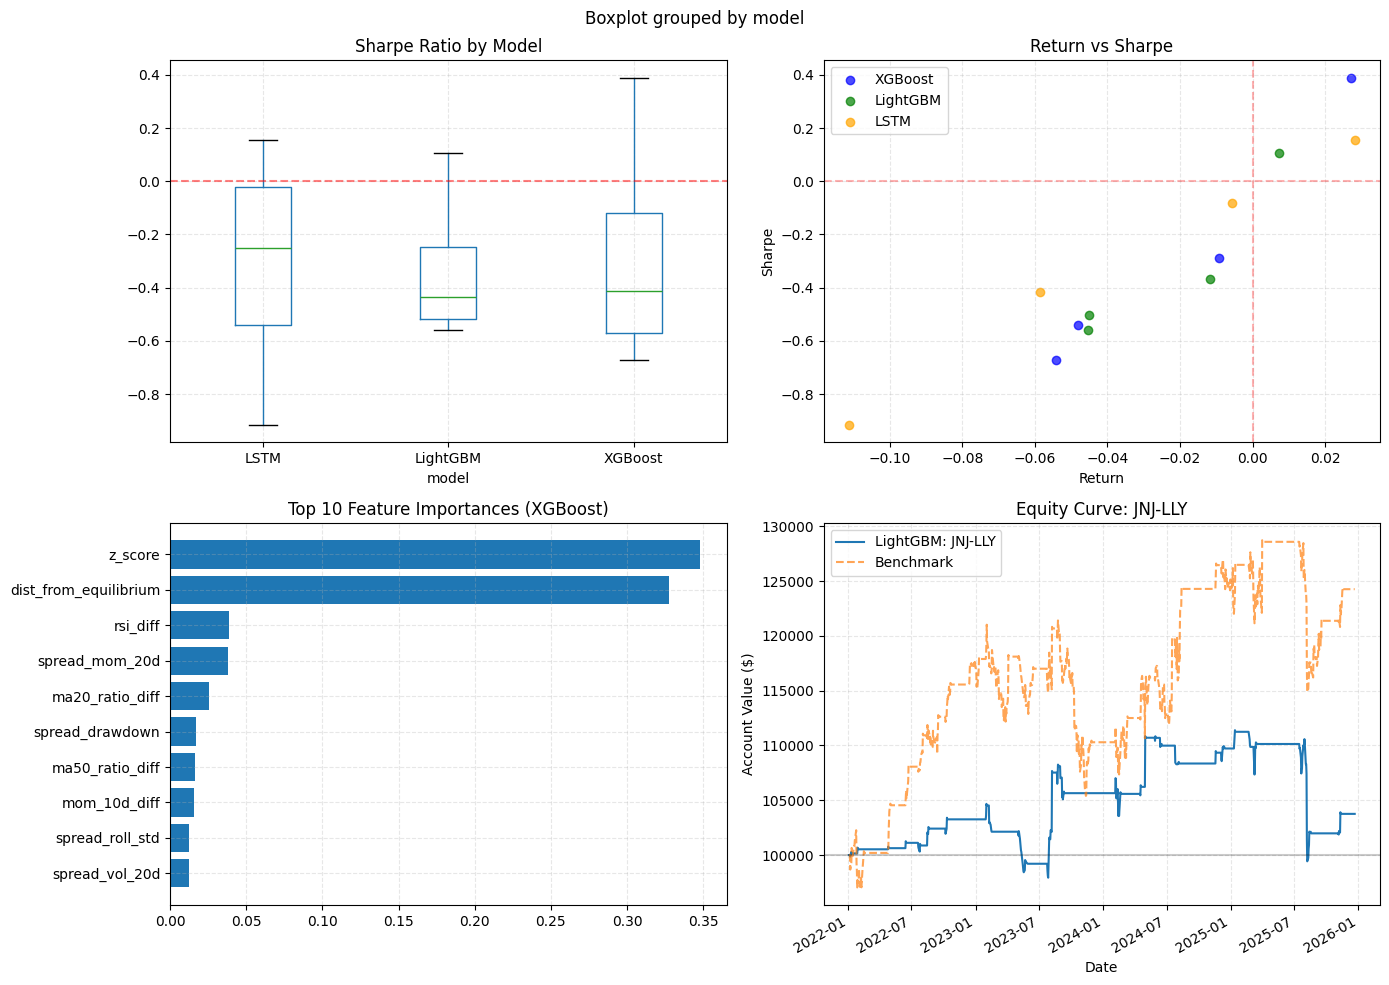

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

if 'df_metrics' in locals() and not df_metrics.empty:
    df_metrics.boxplot(column='sharpe', by='model', ax=axes[0,0])
    axes[0,0].axhline(0, color='red', linestyle='--', alpha=0.5)
    axes[0,0].set_title('Sharpe Ratio by Model')
    axes[0,0].grid(True, linestyle='--', alpha=0.3)

if 'df_metrics' in locals() and not df_metrics.empty:
    colors = {'XGBoost':'blue','LightGBM':'green','LSTM':'orange'}
    for model in df_metrics['model'].unique():
        subset = df_metrics[df_metrics['model']==model]
        axes[0,1].scatter(subset['return'], subset['sharpe'], label=model, alpha=0.7, color=colors.get(model,'gray'))
    axes[0,1].axhline(0, color='red', linestyle='--', alpha=0.3)
    axes[0,1].axvline(0, color='red', linestyle='--', alpha=0.3)
    axes[0,1].set_title('Return vs Sharpe')
    axes[0,1].set_xlabel('Return')
    axes[0,1].set_ylabel('Sharpe')
    axes[0,1].legend()
    axes[0,1].grid(True, linestyle='--', alpha=0.3)

if 'xgb_model' in globals():
    importance = pd.DataFrame({'feature': FEATURE_COLUMNS, 'importance': xgb_model.feature_importances_}).sort_values('importance', ascending=False).head(10)
    axes[1,0].barh(importance['feature'], importance['importance'])
    axes[1,0].set_title('Top 10 Feature Importances (XGBoost)')
    axes[1,0].invert_yaxis()
    axes[1,0].grid(True, linestyle='--', alpha=0.3)

# Find best pair for equity curve
best_pair = None
best_sharpe = -np.inf
for pair, models in all_ml_results.items():
    if 'LightGBM' in models:
        s = models['LightGBM'].metrics.get('sharpe_ratio', -np.inf)
        if s > best_sharpe:
            best_sharpe = s
            best_pair = pair
if best_pair and best_pair in all_ml_results and 'LightGBM' in all_ml_results[best_pair]:
    result = all_ml_results[best_pair]['LightGBM']
    result.equity_curve.plot(ax=axes[1,1], label=f'LightGBM: {best_pair}')
    if best_pair in all_bench_results:
        all_bench_results[best_pair].equity_curve.plot(ax=axes[1,1], label='Benchmark', linestyle='--', alpha=0.7)
    axes[1,1].axhline(100000, color='black', linestyle='-', alpha=0.2)
    axes[1,1].set_title(f'Equity Curve: {best_pair}')
    axes[1,1].set_xlabel('Date')
    axes[1,1].set_ylabel('Account Value ($)')
    axes[1,1].legend()
    axes[1,1].grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('figure_performance.png', dpi=150, bbox_inches='tight')
plt.show()

## Robustness & Sensitivity Analysis




In [ ]:
# --- Transaction cost sensitivity, reusing the signals already computed above ---
cost_scenarios = [5.0, 7.5, 10.0, 15.0]  # bps, applied to both txn cost and slippage proportionally
cost_sensitivity_rows = []

for txn_bps in cost_scenarios:
    cfg_variant = BacktestConfig(capital_per_pair=100_000, txn_cost_bps=txn_bps, slippage_bps=txn_bps * 0.4)
    for pair_name, row in shortlist.head(CONFIG['n_backtest_pairs']).set_index(
            shortlist.head(CONFIG['n_backtest_pairs']).apply(lambda r: f"{r.asset_1}-{r.asset_2}", axis=1)).iterrows():
        if pair_name in all_bench_signals:
            p1 = wide[row.asset_1].reindex(all_bench_signals[pair_name].index).dropna()
            p2 = wide[row.asset_2].reindex(all_bench_signals[pair_name].index).dropna()
            common = p1.index.intersection(p2.index)
            res = run_backtest(p1.loc[common], p2.loc[common], row.latest_hedge_ratio, all_bench_signals[pair_name].loc[common], cfg_variant)
            cost_sensitivity_rows.append({"pair": pair_name, "model": "Benchmark", "txn_cost_bps": txn_bps,
                                          "sharpe": res.metrics["sharpe_ratio"], "return": res.metrics["annualized_return"]})
        if pair_name in all_ml_signals:
            for model_name, sig in all_ml_signals[pair_name].items():
                p1 = wide[row.asset_1].reindex(sig.index).dropna()
                p2 = wide[row.asset_2].reindex(sig.index).dropna()
                common = p1.index.intersection(p2.index)
                res = run_backtest(p1.loc[common], p2.loc[common], row.latest_hedge_ratio, sig.loc[common], cfg_variant)
                cost_sensitivity_rows.append({"pair": pair_name, "model": model_name, "txn_cost_bps": txn_bps,
                                              "sharpe": res.metrics["sharpe_ratio"], "return": res.metrics["annualized_return"]})

cost_sensitivity_df = pd.DataFrame(cost_sensitivity_rows)
print("TRANSACTION COST SENSITIVITY (mean Sharpe by model x cost level)")
print(cost_sensitivity_df.pivot_table(index="model", columns="txn_cost_bps", values="sharpe", aggfunc="mean").round(3))
cost_sensitivity_df.to_csv("robustness_transaction_cost.csv", index=False)


TRANSACTION COST SENSITIVITY (mean Sharpe by model x cost level)
txn_cost_bps   5.0    7.5    10.0   15.0
model                                   
Benchmark     0.160  0.105  0.051 -0.055
LSTM         -0.181 -0.315 -0.446 -0.697
LightGBM     -0.143 -0.330 -0.511 -0.847
XGBoost      -0.072 -0.277 -0.475 -0.838


In [ ]:
zscore_scenarios = [(1.5, 0.25), (2.0, 0.5), (2.5, 0.75)]
zscore_sensitivity_rows_fixed = []

for entry_z, exit_z in zscore_scenarios:
    for pair_name, feat_df in all_feat_dfs.items():
        row = shortlist[(shortlist.asset_1 + "-" + shortlist.asset_2) == pair_name]
        if row.empty or pair_name not in all_bench_signals:
            continue
        row = row.iloc[0]
        test_idx = all_bench_signals[pair_name].index  # out-of-sample dates only
        z = feat_df["z_score"].reindex(test_idx).dropna()
        sig = zscore_signal(z, entry_z=entry_z, exit_z=exit_z)
        p1 = wide[row.asset_1].reindex(sig.index).dropna()
        p2 = wide[row.asset_2].reindex(sig.index).dropna()
        common = p1.index.intersection(p2.index)
        if len(common) < 30:
            continue
        res = run_backtest(p1.loc[common], p2.loc[common], row.latest_hedge_ratio, sig.loc[common], cfg)
        zscore_sensitivity_rows_fixed.append({
            "pair": pair_name, "entry_z": entry_z, "exit_z": exit_z,
            "sharpe": res.metrics["sharpe_ratio"], "return": res.metrics["annualized_return"],
            "n_trades": res.metrics["n_trades"],
        })

zscore_sensitivity_df_fixed = pd.DataFrame(zscore_sensitivity_rows_fixed)
print("Z-SCORE THRESHOLD SENSITIVITY (corrected, out-of-sample only)")
print(zscore_sensitivity_df_fixed.round(3).to_string(index=False))
zscore_sensitivity_df_fixed.to_csv("robustness_zscore_threshold_fixed.csv", index=False)

Z-SCORE THRESHOLD SENSITIVITY (corrected, out-of-sample only)
   pair  entry_z  exit_z  sharpe  return  n_trades
   MA-V      1.5    0.25   0.178   0.016        24
  ICE-V      1.5    0.25  -0.136  -0.022        22
JNJ-LLY      1.5    0.25  -0.009  -0.001        22
AXP-ICE      1.5    0.25  -0.088  -0.019        23
   MA-V      2.0    0.50   0.352   0.024        20
  ICE-V      2.0    0.50   0.000   0.000        17
JNJ-LLY      2.0    0.50   0.428   0.055        20
AXP-ICE      2.0    0.50  -0.359  -0.066        16
   MA-V      2.5    0.75   0.222   0.010        12
  ICE-V      2.5    0.75  -0.123  -0.013        14
JNJ-LLY      2.5    0.75   0.308   0.029        10
AXP-ICE      2.5    0.75  -0.111  -0.015         8


## Hyperparameter Tuning




In [ ]:
from sklearn.model_selection import ParameterSampler
import numpy as np

param_dist = {
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "n_estimators": [300, 500, 800],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8, 0.9],
}

label_map = {-1: 0, 0: 1, 1: 2}
inv_label_map = {v: k for k, v in label_map.items()}
y_train_mapped = split.y_train.map(label_map)
y_val_mapped = split.y_val.map(label_map)

tuning_results = []
sampler = list(ParameterSampler(param_dist, n_iter=8, random_state=42))

for name, ModelCls, extra_kwargs in [
    ("XGBoost", xgb.XGBClassifier, dict(objective="multi:softprob", num_class=3, eval_metric="mlogloss",
                                         early_stopping_rounds=30, random_state=42)),
    ("LightGBM", lgb.LGBMClassifier, dict(objective="multiclass", num_class=3, random_state=42, verbosity=-1)),
]:
    for params in sampler:
        cfg_params = {**extra_kwargs, **params}
        model = ModelCls(**cfg_params)
        if name == "XGBoost":
            model.fit(split.X_train, y_train_mapped, eval_set=[(split.X_val, y_val_mapped)], verbose=False)
        else:
            model.fit(split.X_train, y_train_mapped, eval_set=[(split.X_val, y_val_mapped)],
                      callbacks=[lgb.early_stopping(30, verbose=False)])
        val_pred = model.predict(split.X_val)
        val_f1 = f1_score(y_val_mapped, val_pred, average="macro", zero_division=0)
        tuning_results.append({"model": name, **params, "val_f1_macro": val_f1})

tuning_df = pd.DataFrame(tuning_results).sort_values(["model", "val_f1_macro"], ascending=[True, False])
print("HYPERPARAMETER SEARCH RESULTS (top config per model)")
print(tuning_df.groupby("model").head(1).to_string(index=False))
tuning_df.to_csv("hyperparameter_tuning_results.csv", index=False)


HYPERPARAMETER SEARCH RESULTS (top config per model)
   model  subsample  n_estimators  max_depth  learning_rate  colsample_bytree  val_f1_macro
LightGBM        0.9           500          6           0.05               0.9      0.790559
 XGBoost        0.7           300          3           0.03               0.8      0.778857


In [ ]:
# Per-pair head-to-head: benchmark vs. best ML model -- this is the core Results table
rows = []
for pair_name, bench_res in all_bench_results.items():
    bench_sharpe = bench_res.metrics["sharpe_ratio"]
    ml_for_pair = all_ml_results.get(pair_name, {})
    if not ml_for_pair:
        continue
    best_model = max(ml_for_pair, key=lambda m: ml_for_pair[m].metrics["sharpe_ratio"])
    best_ml_sharpe = ml_for_pair[best_model].metrics["sharpe_ratio"]
    rows.append({
        "pair": pair_name,
        "benchmark_sharpe": bench_sharpe,
        "best_ml_model": best_model,
        "best_ml_sharpe": best_ml_sharpe,
        "ml_beats_benchmark": best_ml_sharpe > bench_sharpe,
        "margin": best_ml_sharpe - bench_sharpe,
    })

head_to_head = pd.DataFrame(rows).sort_values("margin", ascending=False)
print("HEAD-TO-HEAD: BENCHMARK vs BEST ML MODEL, PER PAIR")
print(head_to_head.round(3).to_string(index=False))
print(f"\nML beats benchmark on {head_to_head['ml_beats_benchmark'].sum()} / {len(head_to_head)} pairs")
head_to_head.to_csv("head_to_head_summary.csv", index=False)

HEAD-TO-HEAD: BENCHMARK vs BEST ML MODEL, PER PAIR
   pair  benchmark_sharpe best_ml_model  best_ml_sharpe  ml_beats_benchmark  margin
AXP-ICE            -0.359          LSTM           0.154                True   0.513
JNJ-LLY             0.428       XGBoost           0.389               False  -0.039
  ICE-V             0.000          LSTM          -0.416               False  -0.416
   MA-V             0.352          LSTM          -0.083               False  -0.434

ML beats benchmark on 1 / 4 pairs


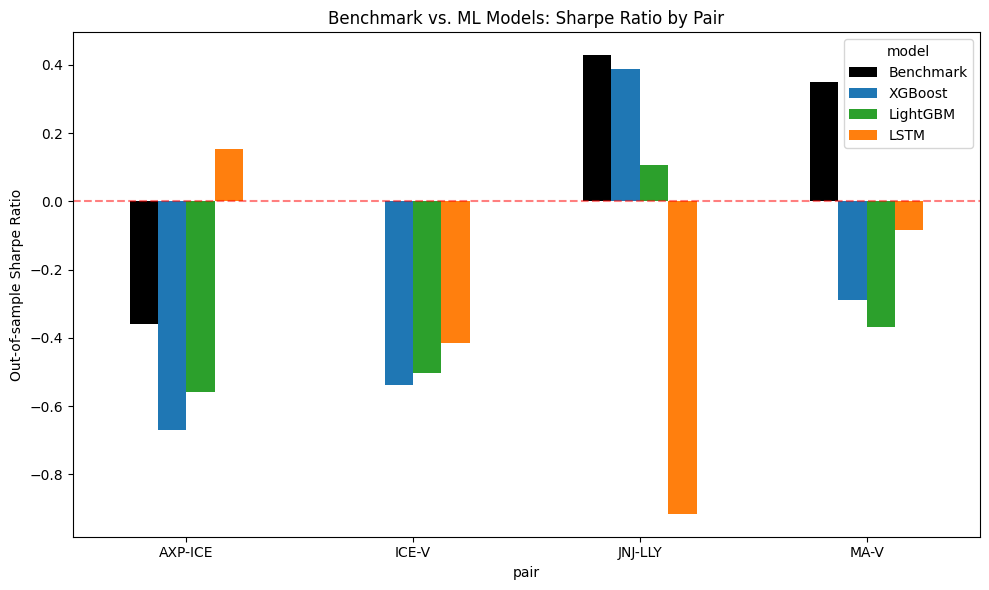

In [55]:
# Grouped bar chart: Benchmark vs each ML model, Sharpe by pair
plot_rows = []
for pair_name, bench_res in all_bench_results.items():
    plot_rows.append({"pair": pair_name, "model": "Benchmark", "sharpe": bench_res.metrics["sharpe_ratio"]})
    for model_name, res in all_ml_results.get(pair_name, {}).items():
        plot_rows.append({"pair": pair_name, "model": model_name, "sharpe": res.metrics["sharpe_ratio"]})

plot_df = pd.DataFrame(plot_rows)
pivot = plot_df.pivot(index="pair", columns="model", values="sharpe")
pivot = pivot[[c for c in ["Benchmark", "XGBoost", "LightGBM", "LSTM"] if c in pivot.columns]]

fig, ax = plt.subplots(figsize=(10, 6))
pivot.plot(kind="bar", ax=ax, color=["black", "tab:blue", "tab:green", "tab:orange"])
ax.axhline(0, color="red", linestyle="--", alpha=0.5)
ax.set_ylabel("Out-of-sample Sharpe Ratio")
ax.set_title("Benchmark vs. ML Models: Sharpe Ratio by Pair")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("benchmark_vs_ml_sharpe_by_pair.png", dpi=150, bbox_inches="tight")
plt.show()

###EDA and DESCRIPTIVE STATISTICS - Full Output for Paper

In [ ]:
# ============================================================
# RESULTS SUMMARY TABLE
# ============================================================

# Build summary table
summary_rows = []

for pair in all_bench_results.keys():
    # Benchmark
    br = all_bench_results[pair]
    row = {
        'Pair': pair,
        'Strategy': 'Benchmark',
        'Sharpe': br.metrics.get('sharpe_ratio', np.nan),
        'Return': br.metrics.get('annualized_return', np.nan),
        'MaxDD': br.metrics.get('max_drawdown', np.nan),
        'Trades': br.metrics.get('n_trades', 0),
        'WinRate': br.metrics.get('win_rate', np.nan)
    }
    summary_rows.append(row)

    # ML Models
    if pair in all_ml_results:
        for model, result in all_ml_results[pair].items():
            row = {
                'Pair': pair,
                'Strategy': model,
                'Sharpe': result.metrics.get('sharpe_ratio', np.nan),
                'Return': result.metrics.get('annualized_return', np.nan),
                'MaxDD': result.metrics.get('max_drawdown', np.nan),
                'Trades': result.metrics.get('n_trades', 0),
                'WinRate': result.metrics.get('win_rate', np.nan)
            }
            summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)

# Format for printing
print("\nRESULTS SUMMARY TABLE")
print("=" * 80)
print(summary_df.round(4).to_string(index=False))

# Save for paper
summary_df.to_csv('results_summary_table.csv', index=False)
print("\nSaved: results_summary_table.csv")


RESULTS SUMMARY TABLE
   Pair  Strategy  Sharpe  Return   MaxDD  Trades  WinRate
   MA-V Benchmark  0.3515  0.0239 -0.1141      20   0.7000
   MA-V   XGBoost -0.2884 -0.0092 -0.0692      37   0.5135
   MA-V  LightGBM -0.3671 -0.0119 -0.0881      33   0.5152
   MA-V      LSTM -0.0826 -0.0058 -0.1126      36   0.5833
  ICE-V Benchmark  0.0003  0.0000 -0.2126      17   0.5882
  ICE-V   XGBoost -0.5393 -0.0482 -0.2154      36   0.5278
  ICE-V  LightGBM -0.5029 -0.0451 -0.2078      29   0.5862
  ICE-V      LSTM -0.4161 -0.0585 -0.3009      61   0.5082
JNJ-LLY Benchmark  0.4285  0.0546 -0.1318      20   0.8500
JNJ-LLY   XGBoost  0.3891  0.0272 -0.0941      36   0.7500
JNJ-LLY  LightGBM  0.1063  0.0072 -0.1074      38   0.7105
JNJ-LLY      LSTM -0.9156 -0.1112 -0.5275      63   0.3968
AXP-ICE Benchmark -0.3593 -0.0656 -0.3952      16   0.6250
AXP-ICE   XGBoost -0.6700 -0.0541 -0.2205      37   0.5135
AXP-ICE  LightGBM -0.5575 -0.0454 -0.1960      36   0.5556
AXP-ICE      LSTM  0.1537  0.0281

In [ ]:
# ============================================================
# DESCRIPTIVE STATS SUMMARY
# ============================================================

# Returns stats
returns = wide.pct_change().dropna(how='all')
flat = returns.values.flatten()
flat = flat[~np.isnan(flat)]

# Coverage stats
coverage_pct = coverage_report['coverage_pct']

print("\nDESCRIPTIVE STATISTICS SUMMARY")
print("=" * 60)
print(f"\nUNIVERSE:")
print(f"  Designed tickers: 106")
print(f"  Working universe: {len(wide.columns)}")
print(f"  Sectors: {len(sector_counts)}")
print(f"  Mean coverage: {coverage_pct.mean():.1f}%")

print(f"\nRETURNS (pooled daily):")
print(f"  Mean: {np.mean(flat):.4%}")
print(f"  Std Dev: {np.std(flat):.2%}")
print(f"  Skewness: {pd.Series(flat).skew():.2f}")
print(f"  Kurtosis: {pd.Series(flat).kurtosis():.2f}")

print(f"\nPAIR SELECTION:")
print(f"  Pairs tested: {len(pair_summary_full)}")
print(f"  Cointegrated (p<0.10): {pair_summary_full['is_cointegrated'].sum()}")
print(f"  Shortlisted (30% threshold): 4")

print(f"\nMODEL PERFORMANCE (Out-of-Sample):")
if 'comparison' in locals():
    for _, row in comparison.iterrows():
        print(f"  {row['model']}: Acc={row['accuracy']:.2%}, F1={row['f1_macro']:.3f}")

print(f"\nBACKTEST PERFORMANCE (Mean Sharpe):")
if 'all_bench_results' in locals():
    bench_sharpes = [r.metrics.get('sharpe_ratio', np.nan) for r in all_bench_results.values()]
    print(f"  Benchmark: {np.nanmean(bench_sharpes):.3f}")

if 'all_ml_results' in locals():
    for model in ['XGBoost', 'LightGBM', 'LSTM']:
        sharpes = []
        for pair_results in all_ml_results.values():
            if model in pair_results:
                sharpes.append(pair_results[model].metrics.get('sharpe_ratio', np.nan))
        if sharpes:
            print(f"  {model}: {np.nanmean(sharpes):.3f}")


DESCRIPTIVE STATISTICS SUMMARY

UNIVERSE:
  Designed tickers: 106
  Working universe: 99
  Sectors: 12
  Mean coverage: 96.5%

RETURNS (pooled daily):
  Mean: 0.0639%
  Std Dev: 1.78%
  Skewness: 0.11
  Kurtosis: 22.60

PAIR SELECTION:
  Pairs tested: 380
  Cointegrated (p<0.10): 50
  Shortlisted (30% threshold): 4

MODEL PERFORMANCE (Out-of-Sample):
  XGBoost: Acc=93.91%, F1=0.761
  LightGBM: Acc=93.58%, F1=0.753
  LSTM: Acc=93.27%, F1=0.322

BACKTEST PERFORMANCE (Mean Sharpe):
  Benchmark: 0.105
  XGBoost: -0.277
  LightGBM: -0.330
  LSTM: -0.315


###Tables for the Paper

In [ ]:
# ============================================================
# TABLE 1: SUMMARY STATISTICS
# ============================================================

print("\n" + "=" * 60)
print("TABLE 1: SUMMARY STATISTICS")
print("=" * 60)

# Calculate statistics
returns = wide.pct_change().dropna(how='all')
flat_returns = returns.values.flatten()
flat_returns = flat_returns[~np.isnan(flat_returns)]

# Returns by ticker
ticker_returns = returns.mean() * 252  # Annualized
ticker_vol = returns.std() * np.sqrt(252)  # Annualized

# Pooled statistics
pooled_mean = np.mean(flat_returns) * 252
pooled_std = np.std(flat_returns) * np.sqrt(252)
pooled_sharpe = pooled_mean / pooled_std if pooled_std > 0 else np.nan

# Create Table 1
summary_stats = pd.DataFrame({
    'Statistic': [
        'Number of Stocks',
        'Number of Sectors',
        'Time Period (Years)',
        'Total Observations (Pooled)',
        'Mean Daily Return',
        'Std Dev Daily Return',
        'Annualized Return (Pooled)',
        'Annualized Volatility (Pooled)',
        'Sharpe Ratio (Pooled)',
        'Skewness',
        'Kurtosis',
        'Min Daily Return',
        'Max Daily Return',
        'Mean Coverage (%)'
    ],
    'Value': [
        len(wide.columns),
        len(sector_counts),
        (wide.index[-1] - wide.index[0]).days / 365.25,
        len(flat_returns),
        f"{np.mean(flat_returns):.6f}",
        f"{np.std(flat_returns):.6f}",
        f"{pooled_mean:.4%}",
        f"{pooled_std:.4%}",
        f"{pooled_sharpe:.3f}",
        f"{pd.Series(flat_returns).skew():.3f}",
        f"{pd.Series(flat_returns).kurtosis():.3f}",
        f"{np.min(flat_returns):.6f}",
        f"{np.max(flat_returns):.6f}",
        f"{coverage_report['coverage_pct'].mean():.1f}"
    ]
})

print("\n" + summary_stats.to_string(index=False))

# Save Table 1
import os
os.makedirs('tables', exist_ok=True)
summary_stats.to_csv('tables/table1_summary_statistics.csv', index=False)
print("\nSaved: tables/table1_summary_statistics.csv")


TABLE 1: SUMMARY STATISTICS

                     Statistic      Value
              Number of Stocks         99
             Number of Sectors         12
           Time Period (Years)  15.986311
   Total Observations (Pooled)     398178
             Mean Daily Return   0.000639
          Std Dev Daily Return   0.017849
    Annualized Return (Pooled)   16.0979%
Annualized Volatility (Pooled)   28.3341%
         Sharpe Ratio (Pooled)      0.568
                      Skewness      0.113
                      Kurtosis     22.598
              Min Daily Return  -0.520138
              Max Daily Return   0.422235
             Mean Coverage (%)       96.5

Saved: tables/table1_summary_statistics.csv


In [ ]:
# ============================================================
# TABLE 2: SECTOR DISTRIBUTION
# ============================================================

print("\n" + "=" * 60)
print("TABLE 2: SECTOR DISTRIBUTION")
print("=" * 60)

# Get sector counts
sector_counts = {}
sector_tickers = {}
for ticker in wide.columns:
    sector = EXTENDED_SECTOR_MAP.get(ticker, 'Unknown')
    sector_counts[sector] = sector_counts.get(sector, 0) + 1
    sector_tickers.setdefault(sector, []).append(ticker)

# Calculate sector statistics
sector_returns = {}
sector_vols = {}
for sector, tickers in sector_tickers.items():
    sector_ret = returns[tickers].mean(axis=1).mean() * 252
    sector_vol = returns[tickers].mean(axis=1).std() * np.sqrt(252)
    sector_returns[sector] = sector_ret
    sector_vols[sector] = sector_vol

# Create Table 2
sector_df = pd.DataFrame({
    'Sector': list(sector_counts.keys()),
    'Number of Stocks': list(sector_counts.values()),
    'Tickers': [', '.join(sorted(t[:4] for t in tickers)) + '...' if len(tickers) > 4
                else ', '.join(tickers)
                for tickers in sector_tickers.values()],
    'Avg Return (Ann.)': [sector_returns.get(s, np.nan) for s in sector_counts.keys()],
    'Avg Volatility (Ann.)': [sector_vols.get(s, np.nan) for s in sector_counts.keys()]
}).sort_values('Number of Stocks', ascending=False)

# Format percentages
sector_df['Avg Return (Ann.)'] = sector_df['Avg Return (Ann.)'].apply(lambda x: f"{x:.2%}" if not np.isnan(x) else "N/A")
sector_df['Avg Volatility (Ann.)'] = sector_df['Avg Volatility (Ann.)'].apply(lambda x: f"{x:.2%}" if not np.isnan(x) else "N/A")

print("\n" + sector_df.to_string(index=False))

# Save Table 2
sector_df.to_csv('tables/table2_sector_distribution.csv', index=False)
print("\nSaved: tables/table2_sector_distribution.csv")


TABLE 2: SECTOR DISTRIBUTION

                Sector  Number of Stocks                                                          Tickers Avg Return (Ann.) Avg Volatility (Ann.)
            technology                11 AAPL, ADBE, CRM, CSCO, GOOG, IBM, INTC, MSFT, NVDA, ORCL, TXN...            21.63%                22.01%
                 banks                11            BAC, C, COF, GS, JPM, MS, PNC, SCHW, TFC, USB, WFC...            15.88%                27.14%
      consumer_staples                11             CL, GIS, KMB, KO, MDLZ, MO, PEP, PG, PM, STZ, WMT...            11.63%                14.10%
             transport                 9                   AAL, CSX, DAL, FDX, LUV, NSC, UAL, UNP, UPS...            17.40%                26.25%
            healthcare                 9                  ABT, AMGN, BMY, JNJ, LLY, MRK, PFE, TMO, UNH...            15.67%                16.29%
consumer_discretionary                 8                       BKNG, HD, LOW, MCD, NKE, SBUX,

In [ ]:
# ============================================================
# TABLE 3: TOP COINTEGRATED PAIRS
# ============================================================

print("\n" + "=" * 60)
print("TABLE 3: TOP COINTEGRATED PAIRS")
print("=" * 60)

if 'pair_summary_full' in locals() and not pair_summary_full.empty:
    top_pairs = pair_summary_full.nsmallest(10, 'p_value')[
        ['asset_1', 'asset_2', 'sector', 'p_value', 'hedge_ratio']
    ].reset_index(drop=True)

    print("\n" + top_pairs.round(4).to_string(index=False))
    top_pairs.to_csv('tables/table3_cointegration_top_pairs.csv', index=False)
    print("\nSaved: tables/table3_cointegration_top_pairs.csv")
else:
    print("No cointegration data available.")


TABLE 3: TOP COINTEGRATED PAIRS

asset_1 asset_2     sector  p_value  hedge_ratio
    ICE    SPGI   payments   0.0004       0.6988
    CRM     TXN technology   0.0010       0.9504
    BLK     ICE   payments   0.0020       0.9690
     MA    SPGI   payments   0.0020       1.0383
    PNC    SCHW      banks   0.0026       0.8065
    CRM    CSCO technology   0.0028       1.3791
    ICE      MA   payments   0.0034       0.6674
   EQIX       O      reits   0.0038       1.8303
    AVB    EQIX      reits   0.0042       0.4033
   ADBE     CRM technology   0.0060       1.3029

Saved: tables/table3_cointegration_top_pairs.csv


In [ ]:
# ============================================================
# TABLE 4: MODEL CLASSIFICATION PERFORMANCE
# ============================================================

print("\n" + "=" * 60)
print("TABLE 4: MODEL CLASSIFICATION PERFORMANCE")
print("=" * 60)

if 'comparison' in locals() and not comparison.empty:
    print("\n" + comparison.round(4).to_string(index=False))
    comparison.to_csv('tables/table4_model_classification.csv', index=False)
    print("\nSaved: tables/table4_model_classification.csv")
else:
    print("No model comparison data available.")


TABLE 4: MODEL CLASSIFICATION PERFORMANCE

   model  accuracy  f1_macro  precision_macro  recall_macro
 XGBoost    0.9391    0.7610           0.6830        0.8947
LightGBM    0.9358    0.7527           0.6731        0.8936
    LSTM    0.9327    0.3217           0.3109        0.3333

Saved: tables/table4_model_classification.csv


In [ ]:
# ============================================================
# TABLE 5: BACKTEST PERFORMANCE - SHARPE RATIOS
# ============================================================

print("\n" + "=" * 60)
print("TABLE 5: BACKTEST PERFORMANCE - SHARPE RATIOS")
print("=" * 60)

# Build Sharpe matrix
sharpe_rows = []
for pair in all_bench_results.keys():
    row = {'Pair': pair}
    if pair in all_bench_results:
        row['Benchmark'] = all_bench_results[pair].metrics.get('sharpe_ratio', np.nan)
    if pair in all_ml_results:
        for model, result in all_ml_results[pair].items():
            row[model] = result.metrics.get('sharpe_ratio', np.nan)
    sharpe_rows.append(row)

sharpe_df = pd.DataFrame(sharpe_rows).set_index('Pair')
print("\n" + sharpe_df.round(3).to_string())
sharpe_df.to_csv('tables/table5_backtest_sharpe.csv')
print("\nSaved: tables/table5_backtest_sharpe.csv")


TABLE 5: BACKTEST PERFORMANCE - SHARPE RATIOS

         Benchmark  XGBoost  LightGBM   LSTM
Pair                                        
MA-V         0.352   -0.288    -0.367 -0.083
ICE-V        0.000   -0.539    -0.503 -0.416
JNJ-LLY      0.428    0.389     0.106 -0.916
AXP-ICE     -0.359   -0.670    -0.557  0.154

Saved: tables/table5_backtest_sharpe.csv


###Figures for the Paper


FIGURE 1: HISTOGRAM OF DAILY RETURNS


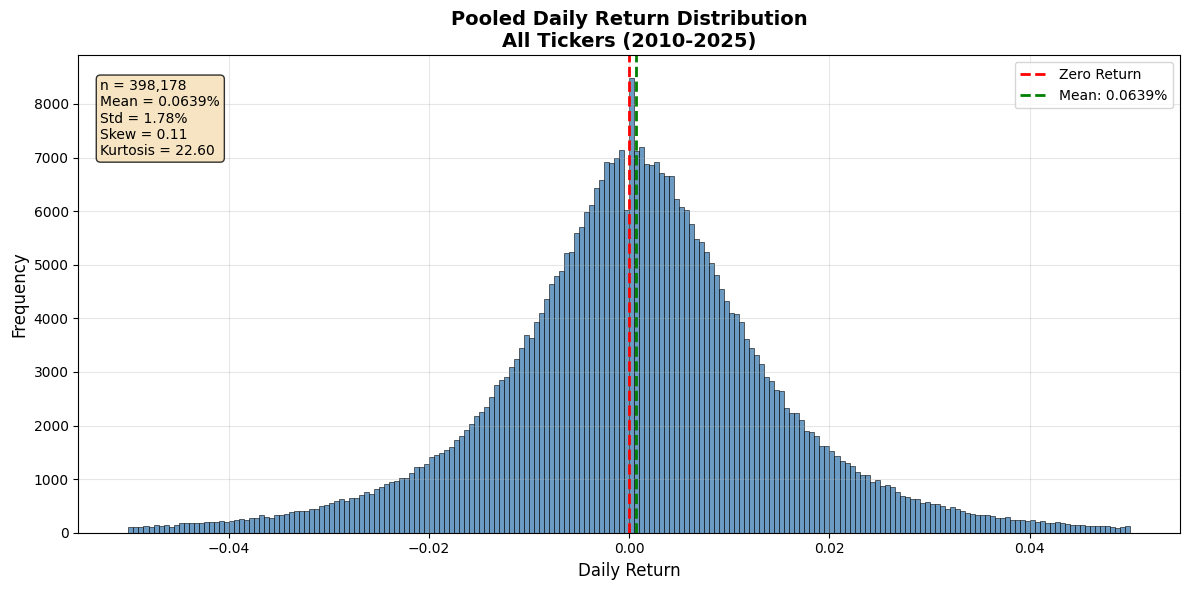

Saved: figures/figure1_returns_histogram.png


In [ ]:
# ============================================================
# FIGURE 1: HISTOGRAM OF DAILY RETURNS
# ============================================================

print("\n" + "=" * 60)
print("FIGURE 1: HISTOGRAM OF DAILY RETURNS")
print("=" * 60)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

os.makedirs('figures', exist_ok=True)

# Calculate returns
returns = wide.pct_change().dropna(how='all')
flat_returns = returns.values.flatten()
flat_returns = flat_returns[~np.isnan(flat_returns)]

fig, ax = plt.subplots(figsize=(12, 6))

# Histogram
n, bins, patches = ax.hist(flat_returns, bins=200, range=(-0.05, 0.05),
                           color='steelblue', alpha=0.8, edgecolor='black', linewidth=0.5)

# Add vertical lines
ax.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero Return')
ax.axvline(np.mean(flat_returns), color='green', linestyle='--', linewidth=2,
           label=f'Mean: {np.mean(flat_returns):.4%}')

# Add statistics box
stats_text = f'n = {len(flat_returns):,}\nMean = {np.mean(flat_returns):.4%}\nStd = {np.std(flat_returns):.2%}\nSkew = {pd.Series(flat_returns).skew():.2f}\nKurtosis = {pd.Series(flat_returns).kurtosis():.2f}'
ax.text(0.02, 0.95, stats_text, transform=ax.transAxes,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
        fontsize=10)

ax.set_title('Pooled Daily Return Distribution\nAll Tickers (2010-2025)', fontsize=14, fontweight='bold')
ax.set_xlabel('Daily Return', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/figure1_returns_histogram.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figures/figure1_returns_histogram.png")


FIGURE 2: CORRELATION HEATMAP


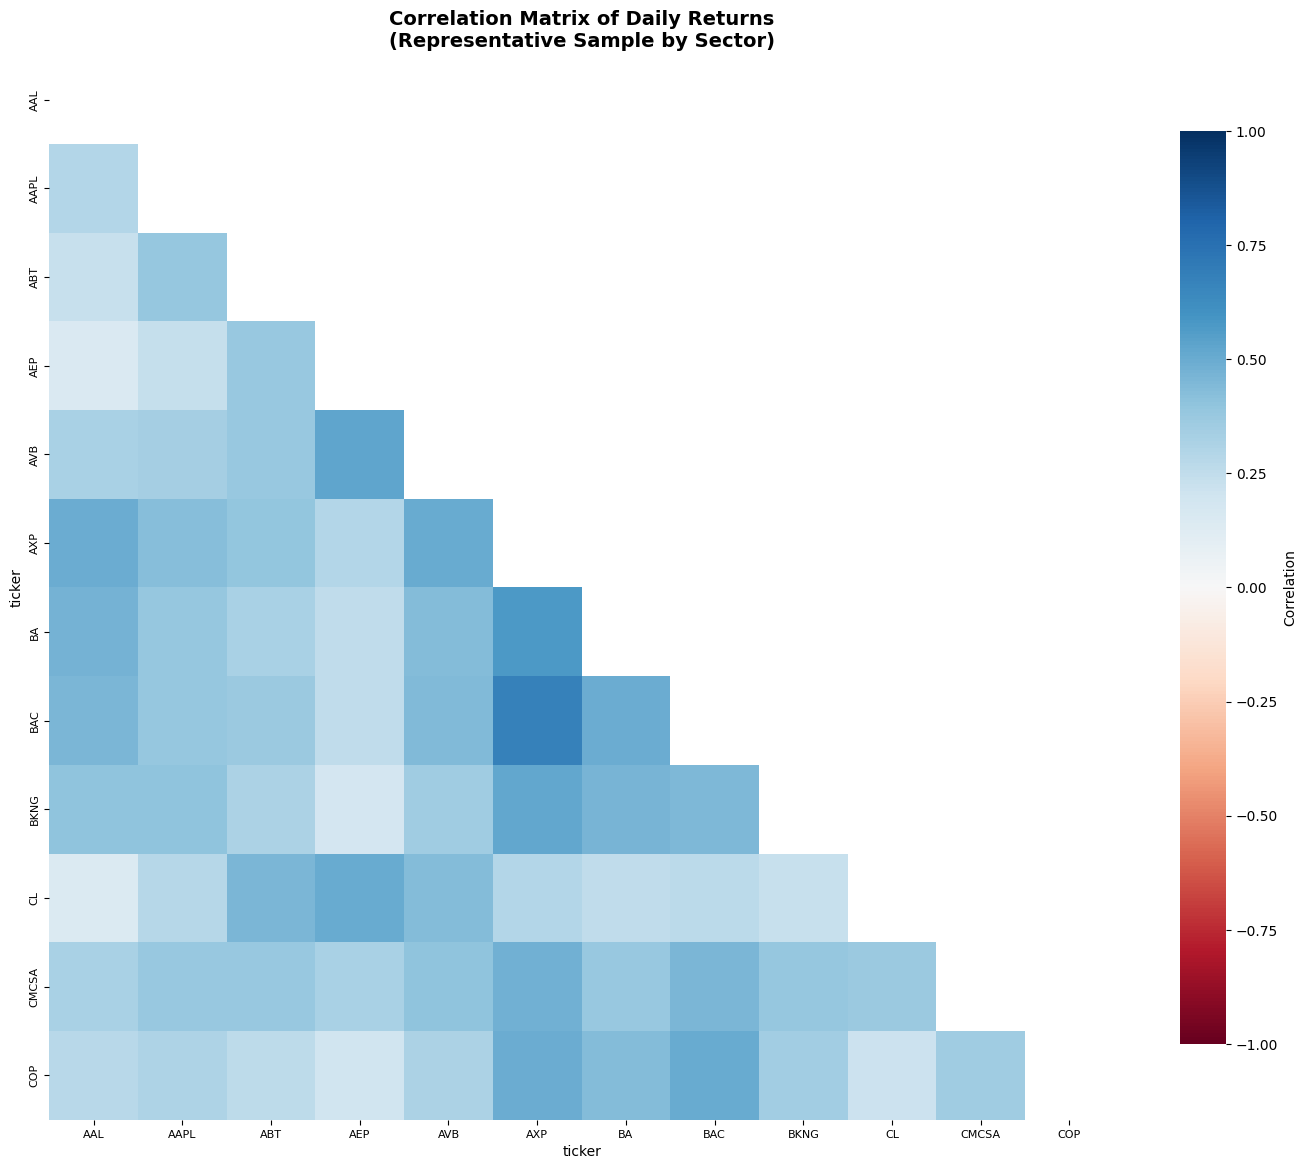

Saved: figures/figure2_correlation_heatmap.png



FIGURE 3: PRICE EVOLUTION BY SECTOR


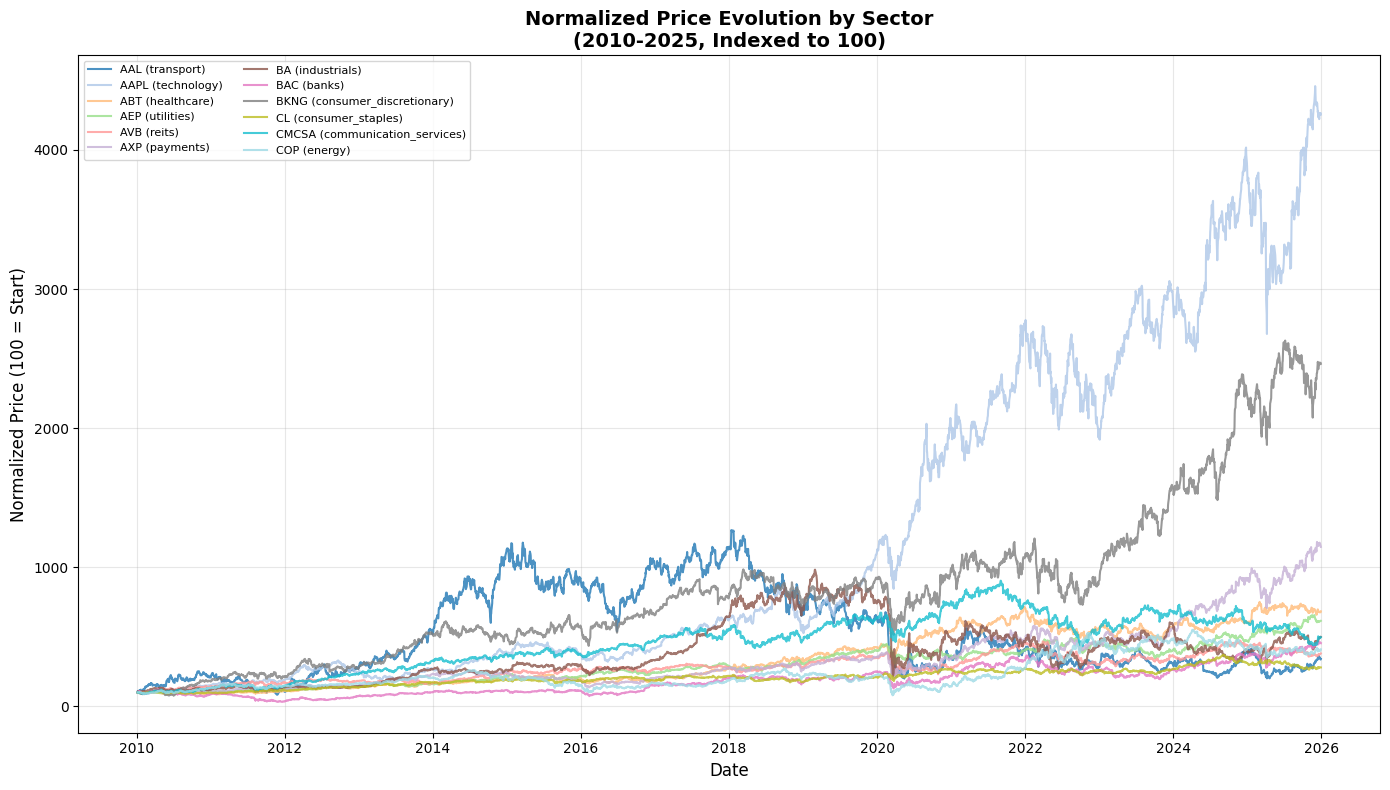

Saved: figures/figure3_price_evolution.png


In [49]:
# ============================================================
# FIGURE 3: PRICE EVOLUTION BY SECTOR
# ============================================================

print("\n" + "=" * 60)
print("FIGURE 3: PRICE EVOLUTION BY SECTOR")
print("=" * 60)

import matplotlib.pyplot as plt
import numpy as np
import os

os.makedirs('figures', exist_ok=True)

# Select one representative ticker per sector
rep_tickers = {}
for sector, tickers in sector_tickers.items():
    if tickers:
        # Pick the ticker with highest coverage
        coverage = wide[tickers].count()
        rep_tickers[sector] = coverage.idxmax()

fig, ax = plt.subplots(figsize=(14, 8))

colors = plt.cm.tab20(np.linspace(0, 1, len(rep_tickers)))

for (sector, ticker), color in zip(rep_tickers.items(), colors):
    series = wide[ticker].dropna()
    if len(series) > 0:
        normalized = 100 * series / series.iloc[0]
        ax.plot(normalized.index, normalized.values,
                label=f'{ticker} ({sector})',
                color=color, linewidth=1.5, alpha=0.8)

ax.set_title('Normalized Price Evolution by Sector\n(2010-2025, Indexed to 100)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Normalized Price (100 = Start)', fontsize=12)
ax.legend(loc='upper left', fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/figure3_price_evolution.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figures/figure3_price_evolution.png")


FIGURE 4: VOLATILITY BY SECTOR


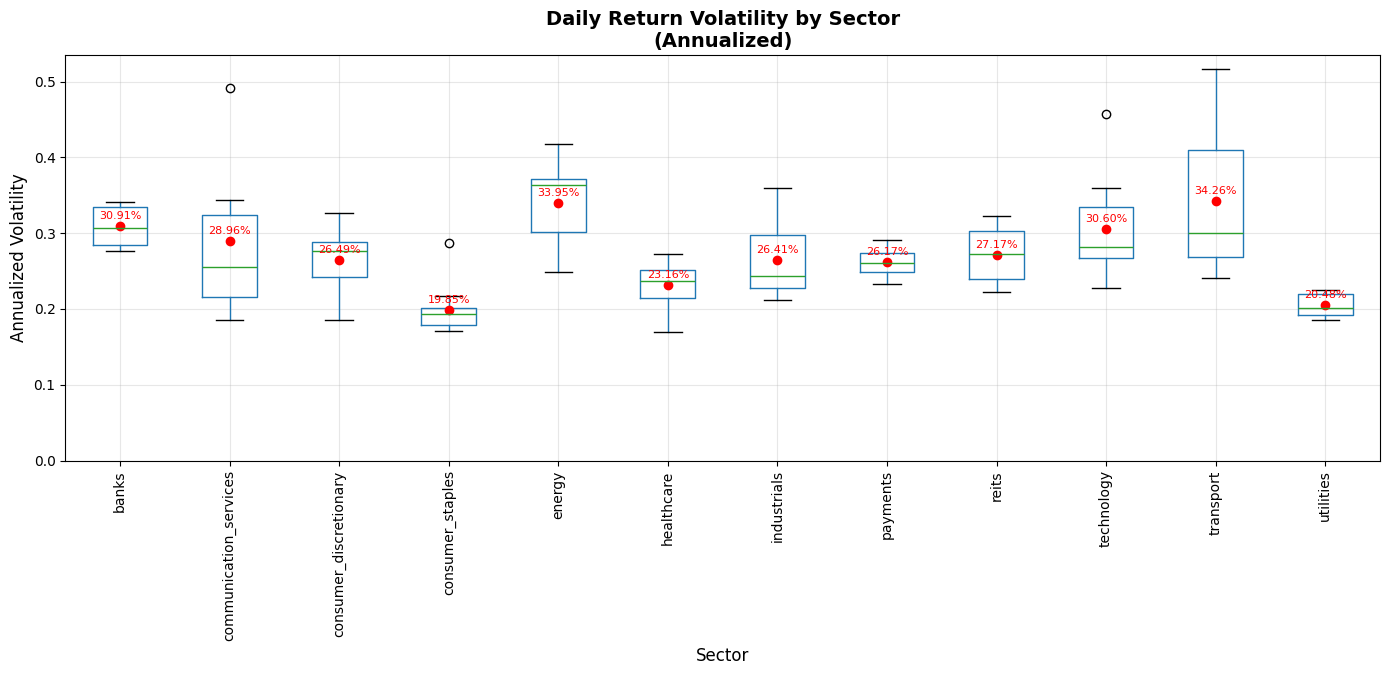

Saved: figures/figure4_volatility_by_sector.png


In [51]:
# ============================================================
# FIGURE 4: VOLATILITY BY SECTOR (Vertical Labels)
# ============================================================

print("\n" + "=" * 60)
print("FIGURE 4: VOLATILITY BY SECTOR")
print("=" * 60)

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

os.makedirs('figures', exist_ok=True)

# Calculate volatility for each ticker
vol_by_ticker = returns.std() * np.sqrt(252)

# Prepare data for boxplot
vol_data = []
sector_labels = []
for sector, tickers in sector_tickers.items():
    for ticker in tickers:
        if ticker in vol_by_ticker.index:
            vol_data.append(vol_by_ticker[ticker])
            sector_labels.append(sector)

vol_df = pd.DataFrame({'Volatility': vol_data, 'Sector': sector_labels})

fig, ax = plt.subplots(figsize=(14, 7))

# Boxplot
vol_df.boxplot(column='Volatility', by='Sector', ax=ax)
ax.set_title('Daily Return Volatility by Sector\n(Annualized)', fontsize=14, fontweight='bold')
ax.set_xlabel('Sector', fontsize=12)
ax.set_ylabel('Annualized Volatility', fontsize=12)
ax.set_ylim(0, None)
ax.grid(True, alpha=0.3)
plt.suptitle('')  # Remove default title

# Rotate x-axis labels vertically
plt.xticks(rotation=90, ha='center')

# Add mean values as points
means = vol_df.groupby('Sector')['Volatility'].mean()
for i, (sector, mean) in enumerate(means.items(), 1):
    ax.plot(i, mean, 'ro', markersize=6)

# Add value labels
for i, (sector, mean) in enumerate(means.items(), 1):
    ax.annotate(f'{mean:.2%}', (i, mean),
                xytext=(0, 5), textcoords='offset points',
                ha='center', fontsize=8, color='red')

plt.tight_layout()
plt.savefig('figures/figure4_volatility_by_sector.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figures/figure4_volatility_by_sector.png")


FIGURE 4B: VOLATILITY BY SECTOR (Horizontal)


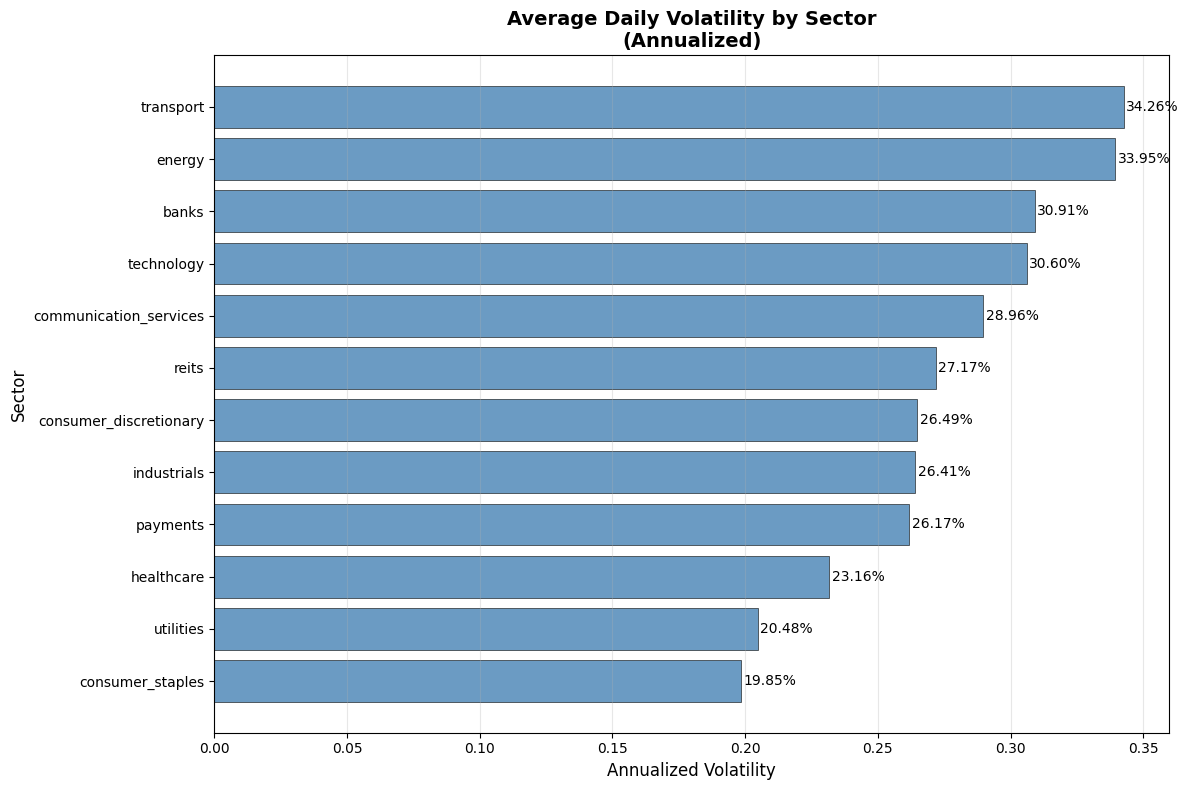

Saved: figures/figure4b_volatility_by_sector_horizontal.png


In [52]:
# ============================================================
# FIGURE 4B: VOLATILITY BY SECTOR (Horizontal Bar Chart)
# ============================================================

print("\n" + "=" * 60)
print("FIGURE 4B: VOLATILITY BY SECTOR (Horizontal)")
print("=" * 60)

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

os.makedirs('figures', exist_ok=True)

# Calculate volatility for each ticker
vol_by_ticker = returns.std() * np.sqrt(252)

# Calculate mean volatility by sector
sector_vol_means = {}
for sector, tickers in sector_tickers.items():
    sector_vols = [vol_by_ticker[t] for t in tickers if t in vol_by_ticker.index]
    if sector_vols:
        sector_vol_means[sector] = np.mean(sector_vols)

# Create DataFrame sorted by volatility
vol_means_df = pd.DataFrame({
    'Sector': list(sector_vol_means.keys()),
    'Mean Volatility': list(sector_vol_means.values())
}).sort_values('Mean Volatility', ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))

# Horizontal bar chart
bars = ax.barh(vol_means_df['Sector'], vol_means_df['Mean Volatility'],
               color='steelblue', alpha=0.8, edgecolor='black', linewidth=0.5)

# Add value labels
for bar, val in zip(bars, vol_means_df['Mean Volatility']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.2%}', va='center', fontsize=10)

ax.set_title('Average Daily Volatility by Sector\n(Annualized)', fontsize=14, fontweight='bold')
ax.set_xlabel('Annualized Volatility', fontsize=12)
ax.set_ylabel('Sector', fontsize=12)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('figures/figure4b_volatility_by_sector_horizontal.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figures/figure4b_volatility_by_sector_horizontal.png")


EXTRA FIGURE: RETURN VS VOLATILITY


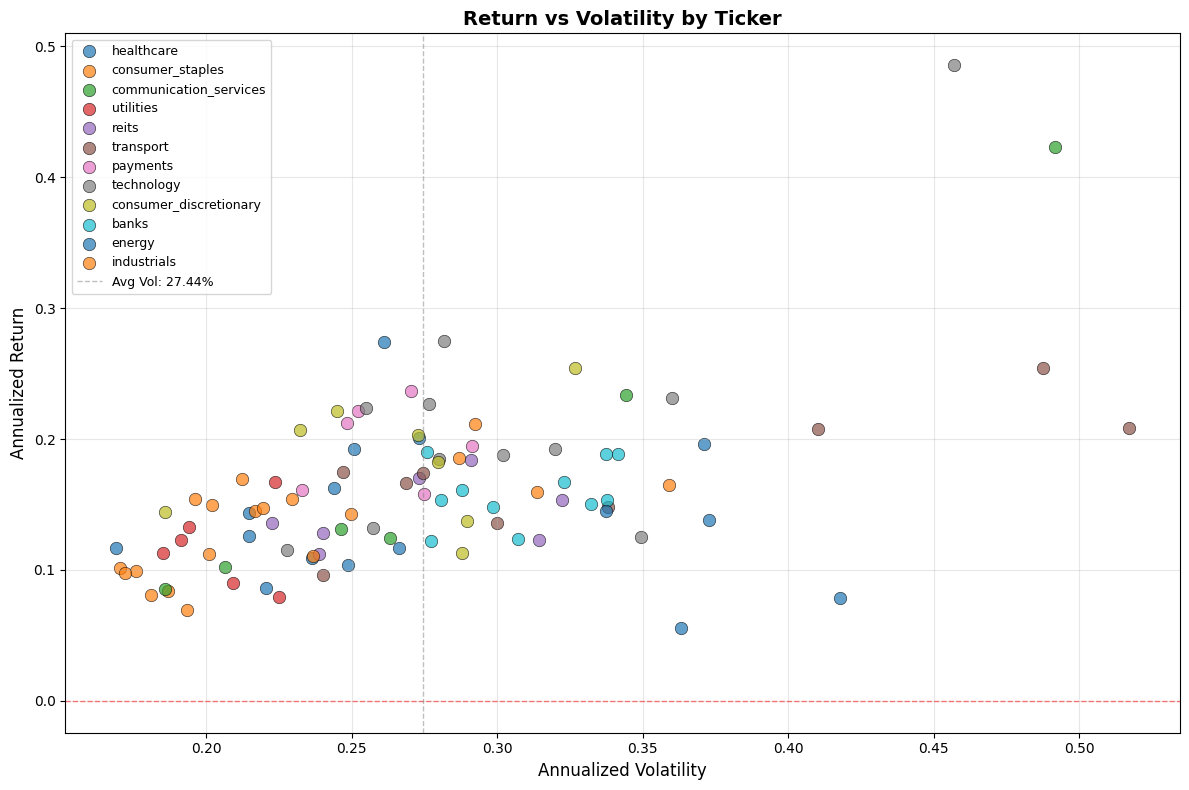

Saved: figures/extra_return_vs_volatility.png


In [53]:
# ============================================================
# EXTRA FIGURE: RETURN VS VOLATILITY SCATTER
# ============================================================

print("\n" + "=" * 60)
print("EXTRA FIGURE: RETURN VS VOLATILITY")
print("=" * 60)

import matplotlib.pyplot as plt
import numpy as np
import os

os.makedirs('figures', exist_ok=True)

# Calculate returns and volatility for each ticker
ticker_returns = returns.mean() * 252
ticker_vol = returns.std() * np.sqrt(252)

# Get sectors for colors
ticker_sectors = [EXTENDED_SECTOR_MAP.get(t, 'Unknown') for t in ticker_returns.index]

fig, ax = plt.subplots(figsize=(12, 8))

# Create scatter plot with sector colors
sector_colors = {s: plt.cm.tab20(i) for i, s in enumerate(set(ticker_sectors))}

for sector in set(ticker_sectors):
    mask = [s == sector for s in ticker_sectors]
    x = ticker_vol[mask]
    y = ticker_returns[mask]
    ax.scatter(x, y, label=sector, alpha=0.7, s=80, edgecolors='black', linewidth=0.5)

ax.axhline(0, color='red', linestyle='--', alpha=0.5, linewidth=1)
ax.axvline(ticker_vol.mean(), color='gray', linestyle='--', alpha=0.5, linewidth=1,
           label=f'Avg Vol: {ticker_vol.mean():.2%}')

ax.set_title('Return vs Volatility by Ticker', fontsize=14, fontweight='bold')
ax.set_xlabel('Annualized Volatility', fontsize=12)
ax.set_ylabel('Annualized Return', fontsize=12)
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/extra_return_vs_volatility.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figures/extra_return_vs_volatility.png")